In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('/content/cleaned_global_weather_monthly.csv')

In [21]:
print(df.head(5))

       country location_name  year  month  temperature_celsius  wind_mps  \
0  Afghanistan         Kabul  2024      5            20.305882  3.199346   
1  Afghanistan         Kabul  2024      6            25.590000  4.752778   
2  Afghanistan         Kabul  2024      7            31.303448  5.758621   
3  Afghanistan         Kabul  2024      8            30.848387  5.610215   
4  Afghanistan         Kabul  2024      9            28.216667  3.395370   

     pressure_pa  precip_mm   humidity      cloud  uv_index  \
0  101000.000000   0.108824  38.058824  31.764706  3.764706   
1  100490.000000   0.072667  24.833333  20.833333  6.500000   
2   99800.000000   0.000345  17.931034  13.068966  7.758621   
3  100125.806452   0.037097  20.548387  11.903226  7.483871   
4  100480.000000   0.014333  13.733333  13.066667  7.000000   

   air_quality_PM2.5  air_quality_PM10  
0           7.894118         17.411765  
1           7.380000         16.786667  
2           9.065517         23.596552  


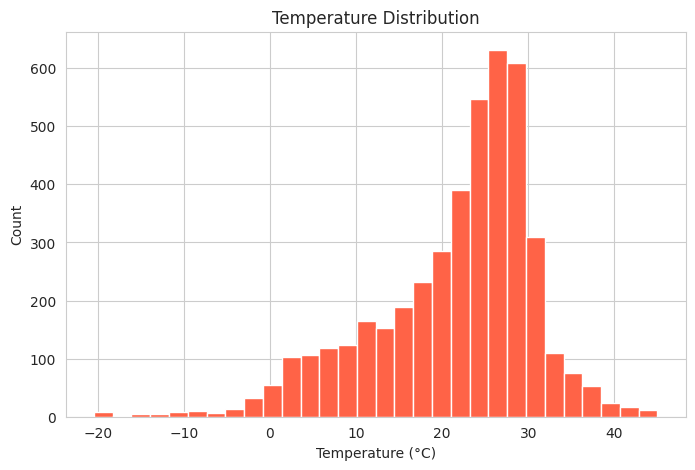

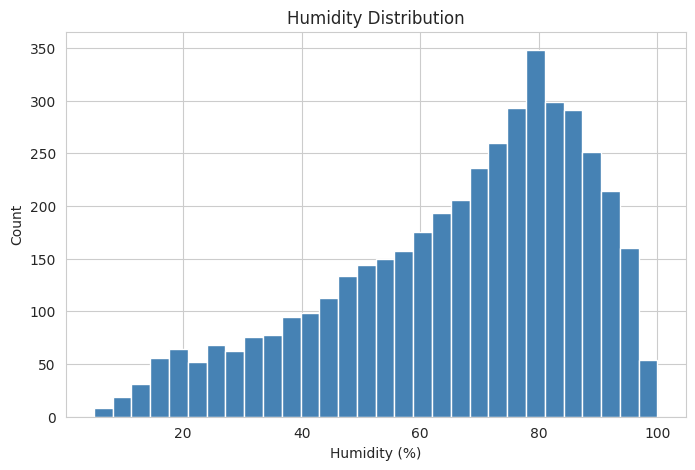

In [23]:
# Distributions
plt.figure(figsize=(8, 5))
plt.hist(df['temperature_celsius'], bins=30, color='tomato', edgecolor='white')
plt.title('Temperature Distribution')
plt.xlabel('Temperature (°C)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df['humidity'], bins=30, color='steelblue', edgecolor='white')
plt.title('Humidity Distribution')
plt.xlabel('Humidity (%)')
plt.ylabel('Count')
plt.show()

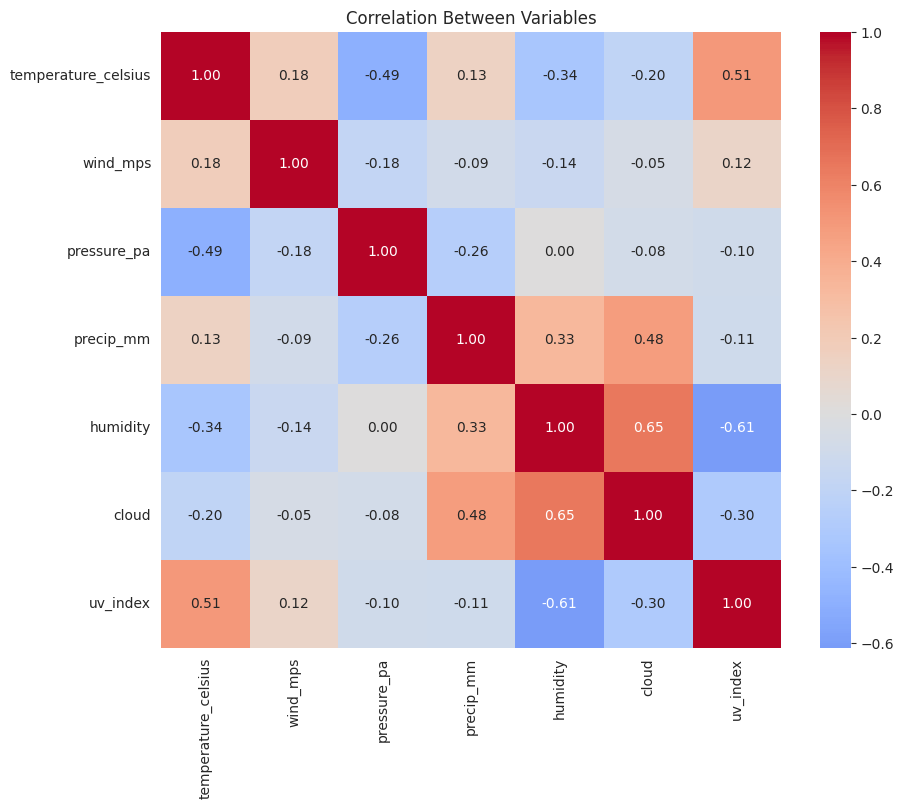

In [24]:
#Correlation Heatmap
plt.figure(figsize=(10, 8))
num_cols = ['temperature_celsius', 'wind_mps', 'pressure_pa',
            'precip_mm', 'humidity', 'cloud', 'uv_index']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Correlation Between Variables')
plt.show()


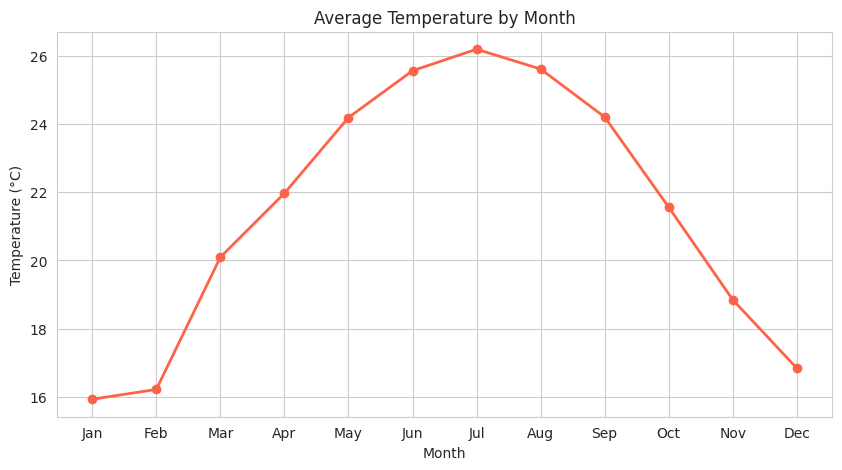

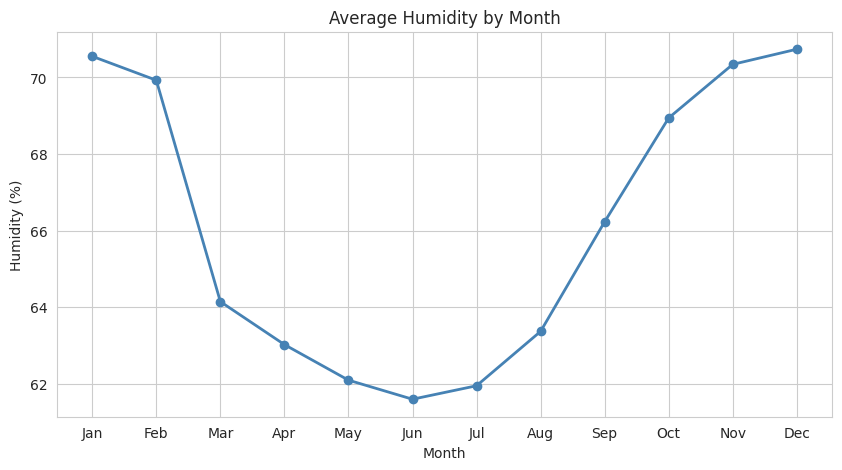

In [25]:
#  Average Temperature by Month
monthly_temp = df.groupby('month')['temperature_celsius'].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_temp.index, monthly_temp.values, marker='o', color='tomato', linewidth=2)
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Average Temperature by Month')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()


#  Average Humidity by Month
monthly_humidity = df.groupby('month')['humidity'].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_humidity.index, monthly_humidity.values, marker='o', color='steelblue', linewidth=2)
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Average Humidity by Month')
plt.xlabel('Month')
plt.ylabel('Humidity (%)')
plt.grid(True)
plt.show()

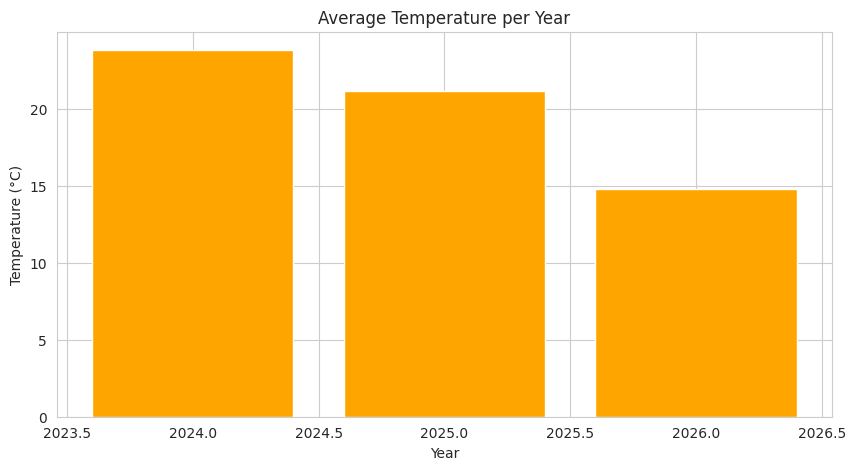

In [28]:
#  Yearly Average Temperature Trend
yearly_temp = df.groupby('year')['temperature_celsius'].mean()

plt.figure(figsize=(10, 5))
plt.bar(yearly_temp.index, yearly_temp.values, color='orange', edgecolor='white')
plt.title('Average Temperature per Year')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.show()


<Figure size 1200x500 with 0 Axes>

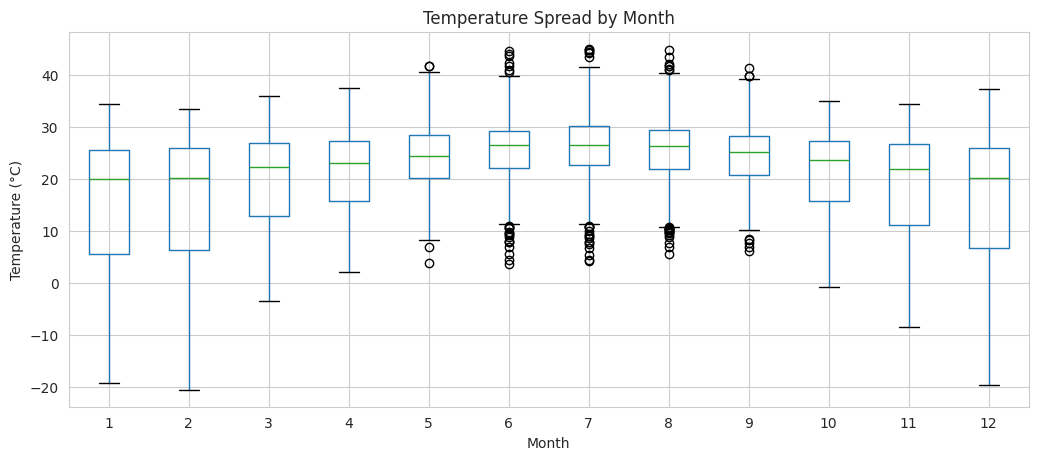

In [26]:
# Temperature by Month (Box Plot)
plt.figure(figsize=(12, 5))
df.boxplot(column='temperature_celsius', by='month', figsize=(12, 5))
plt.title('Temperature Spread by Month')
plt.suptitle('')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.show()

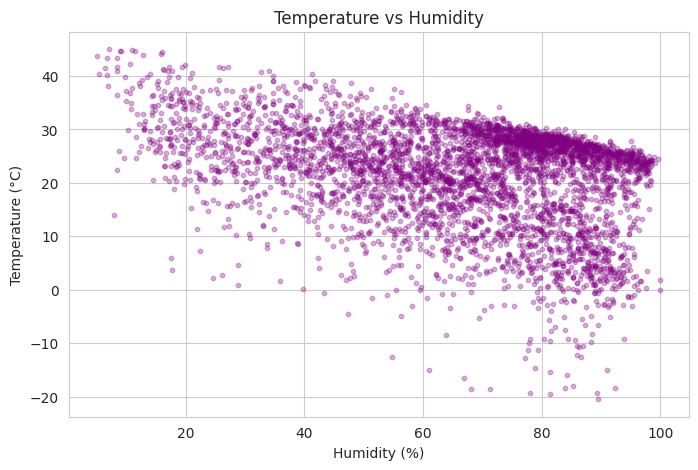

In [27]:
# Temperature vs Humidity Scatter Plot
plt.figure(figsize=(8, 5))
plt.scatter(df['humidity'], df['temperature_celsius'], alpha=0.3, color='purple', s=10)
plt.title('Temperature vs Humidity')
plt.xlabel('Humidity (%)')
plt.ylabel('Temperature (°C)')
plt.show()

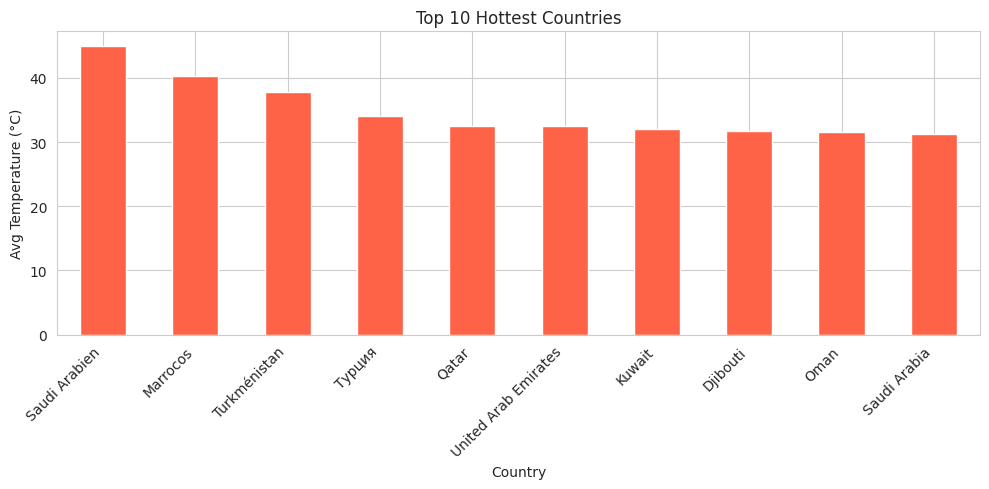

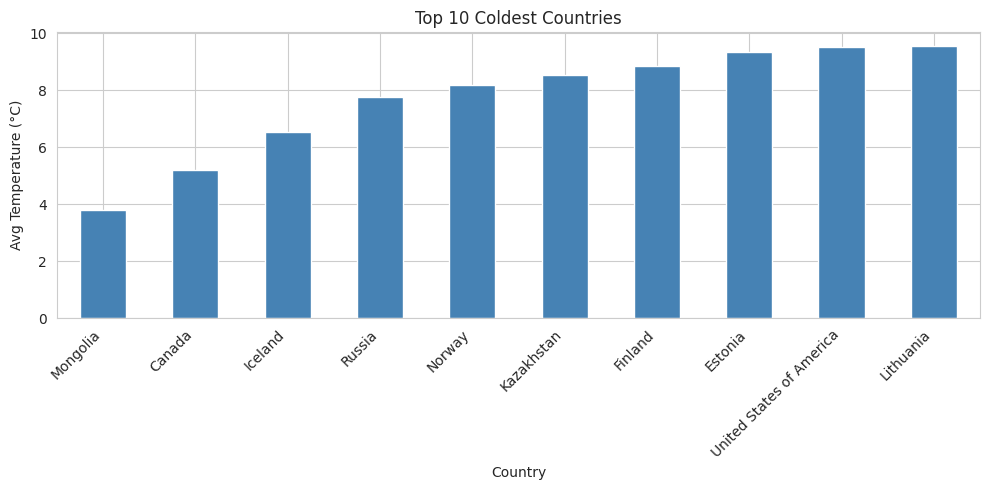

In [33]:
# CELL 12 - Top 10 Hottest Countries
top_hot = df.groupby('country')['temperature_celsius'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_hot.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Top 10 Hottest Countries')
plt.xlabel('Country')
plt.ylabel('Avg Temperature (°C)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# CELL 13 - Top 10 Coldest Countries
top_cold = df.groupby('country')['temperature_celsius'].mean().sort_values().head(10)

plt.figure(figsize=(10, 5))
top_cold.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 10 Coldest Countries')
plt.xlabel('Country')
plt.ylabel('Avg Temperature (°C)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [30]:
# CELL 16 - Summary
print("========== SUMMARY ==========")
print(f"Total Records  : {df.shape[0]}")
print(f"Countries      : {df['country'].nunique()}")
print(f"Hottest Country: {df.groupby('country')['temperature_celsius'].mean().idxmax()}")
print(f"Coldest Country: {df.groupby('country')['temperature_celsius'].mean().idxmin()}")
print(f"Avg Temperature: {df['temperature_celsius'].mean():.2f} °C")
print(f"Avg Humidity   : {df['humidity'].mean():.1f} %")
print("==============================")

========== SUMMARY ==========
Total Records  : 4385
Countries      : 211
Hottest Country: Saudi Arabien
Coldest Country: Mongolia
Avg Temperature: 21.53 °C
Avg Humidity   : 66.2 %


===== DATA RANGES =====
temperature_celsius          Min: -20.5   Max: 45.0   Mean: 21.5
precip_mm                    Min: 0.0   Max: 2.3   Mean: 0.1
wind_mps                     Min: 1.0   Max: 32.5   Mean: 3.6
humidity                     Min: 5.0   Max: 100.0   Mean: 66.2
uv_index                     Min: 0.0   Max: 14.3   Mean: 3.5
air_quality_PM2.5            Min: 0.5   Max: 764.9   Mean: 24.1
✅ Extreme event flags created!
======= EXTREME EVENT COUNTS =======
🔥 Extreme Heat      temp > 40°C     : 32
🥶 Extreme Cold      temp < -10°C    : 24
💨 Strong Winds      > 15 m/s        : 1
💧 High Humidity     > 95%           : 136
☀️  Dangerous UV      > 10            : 201
🏭 Bad Air Quality   PM2.5 > 100     : 118
🌧️  Heavy Rainfall    > 1.5 mm        : 12


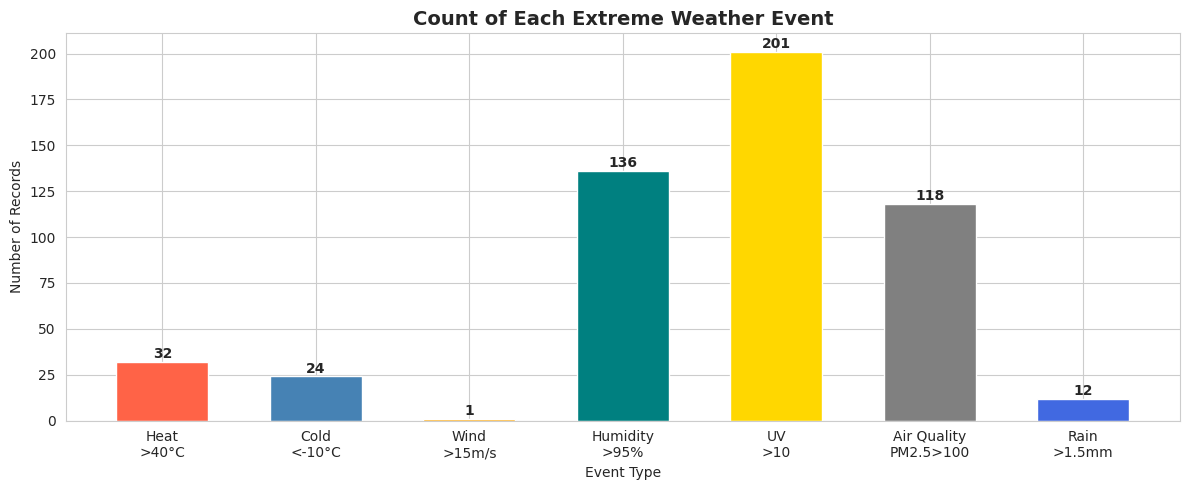

✅ Total extreme event records : 494
   Out of total records        : 4385
   Percentage extreme          : 11.3%


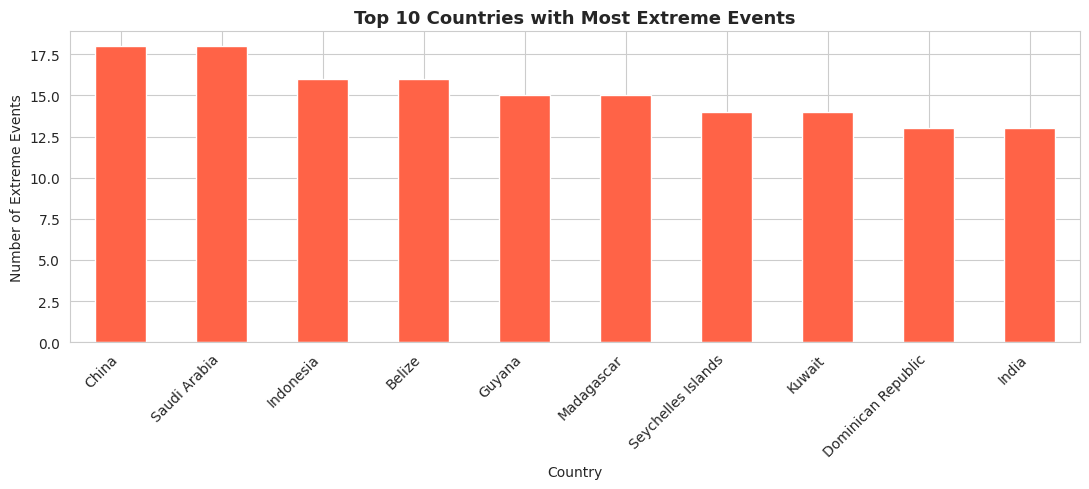

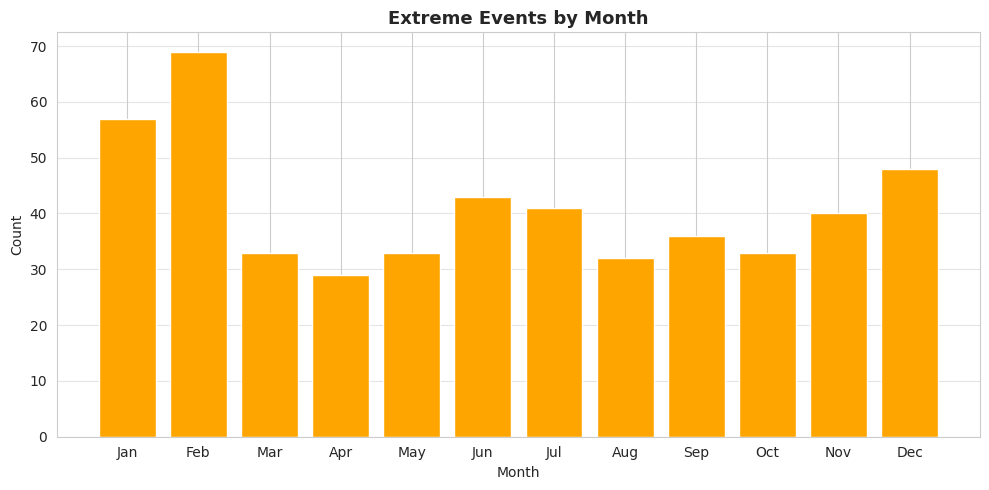

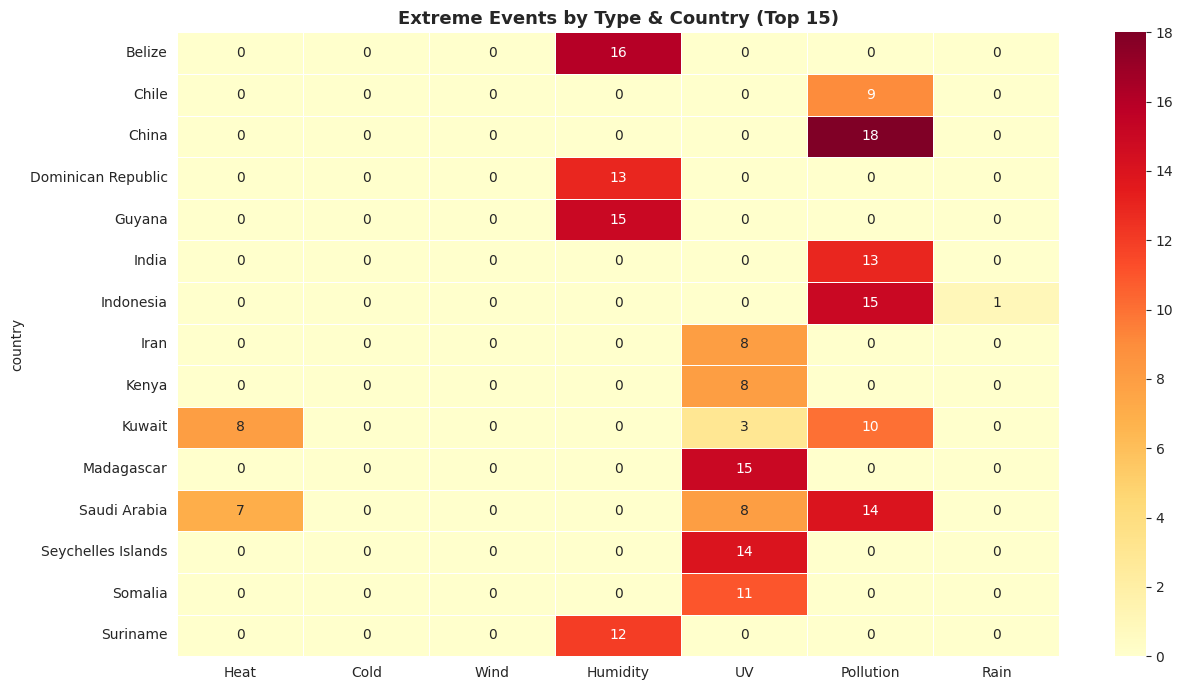

Sample Extreme Weather Records:
======= FINAL SUMMARY =======
Total records             : 4385
Extreme event records     : 494
% extreme                 : 11.3%
Most affected country     : China
Worst month               : 2
Highest temp              : 45.0 °C  →  Saudi Arabien
Lowest temp               : -20.5 °C  →  Russia
Highest wind              : 32.5 m/s  →  Burundi
Worst air quality (PM2.5) : 764.9  →  Chile


In [34]:
# =====================================================
#   EXTREME WEATHER EVENTS
# =====================================================

# Check Data Ranges (before setting thresholds)
cols = ['temperature_celsius', 'precip_mm', 'wind_mps',
        'humidity', 'uv_index', 'air_quality_PM2.5']

print("===== DATA RANGES =====")
for col in cols:
    print(f"{col:<28} Min: {df[col].min():.1f}   Max: {df[col].max():.1f}   Mean: {df[col].mean():.1f}")


# Flag Extreme Weather Events
# Thresholds based on actual data ranges

df['extreme_heat']      = df['temperature_celsius'] > 40      # Top hottest
df['extreme_cold']      = df['temperature_celsius'] < -10     # Top coldest
df['extreme_wind']      = df['wind_mps'] > 15                 # Strong winds
df['extreme_humidity']  = df['humidity'] > 95                 # Very humid
df['extreme_uv']        = df['uv_index'] > 10                 # Dangerous UV
df['extreme_pollution'] = df['air_quality_PM2.5'] > 100       # Unhealthy air
df['extreme_rain']      = df['precip_mm'] > 1.5               # Heavy rainfall

print("✅ Extreme event flags created!")


# CCount Each Extreme Event
print("======= EXTREME EVENT COUNTS =======")
print(f"🔥 Extreme Heat      temp > 40°C     : {df['extreme_heat'].sum()}")
print(f"🥶 Extreme Cold      temp < -10°C    : {df['extreme_cold'].sum()}")
print(f"💨 Strong Winds      > 15 m/s        : {df['extreme_wind'].sum()}")
print(f"💧 High Humidity     > 95%           : {df['extreme_humidity'].sum()}")
print(f"☀️  Dangerous UV      > 10            : {df['extreme_uv'].sum()}")
print(f"🏭 Bad Air Quality   PM2.5 > 100     : {df['extreme_pollution'].sum()}")
print(f"🌧️  Heavy Rainfall    > 1.5 mm        : {df['extreme_rain'].sum()}")
print("=====================================")


#  Bar Chart: Count of Each Extreme Event
event_names  = ['Heat\n>40°C', 'Cold\n<-10°C', 'Wind\n>15m/s',
                'Humidity\n>95%', 'UV\n>10', 'Air Quality\nPM2.5>100', 'Rain\n>1.5mm']
event_counts = [df['extreme_heat'].sum(), df['extreme_cold'].sum(),
                df['extreme_wind'].sum(), df['extreme_humidity'].sum(),
                df['extreme_uv'].sum(), df['extreme_pollution'].sum(),
                df['extreme_rain'].sum()]
colors = ['tomato','steelblue','orange','teal','gold','gray','royalblue']

plt.figure(figsize=(12, 5))
plt.bar(event_names, event_counts, color=colors, edgecolor='white', width=0.6)
plt.title('Count of Each Extreme Weather Event', fontsize=14, fontweight='bold')
plt.ylabel('Number of Records')
plt.xlabel('Event Type')
for i, v in enumerate(event_counts):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


# Combine: Any Extreme Event in a Row
df['any_extreme'] = (
    df['extreme_heat'] | df['extreme_cold'] | df['extreme_wind'] |
    df['extreme_humidity'] | df['extreme_uv'] | df['extreme_pollution'] | df['extreme_rain']
)

extreme_df = df[df['any_extreme'] == True].copy()
print(f"✅ Total extreme event records : {len(extreme_df)}")
print(f"   Out of total records        : {len(df)}")
print(f"   Percentage extreme          : {len(extreme_df)/len(df)*100:.1f}%")


# Top 10 Countries with Most Extreme Events
top_countries = extreme_df['country'].value_counts().head(10)

plt.figure(figsize=(11, 5))
top_countries.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Top 10 Countries with Most Extreme Events', fontsize=13, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Number of Extreme Events')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Extreme Events by Month
extreme_by_month = extreme_df.groupby('month').size()

plt.figure(figsize=(10, 5))
plt.bar(extreme_by_month.index, extreme_by_month.values, color='orange', edgecolor='white')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Extreme Events by Month', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()


# Heatmap: Which Country Has Which Extreme Events
top15 = extreme_df['country'].value_counts().head(15).index
event_cols = ['extreme_heat','extreme_cold','extreme_wind',
              'extreme_humidity','extreme_uv','extreme_pollution','extreme_rain']

heatmap_data = df[df['country'].isin(top15)].groupby('country')[event_cols].sum()
heatmap_data.columns = ['Heat','Cold','Wind','Humidity','UV','Pollution','Rain']

plt.figure(figsize=(13, 7))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Extreme Events by Type & Country (Top 15)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# View Sample Extreme Records
cols_show = ['country','location_name','year','month',
             'temperature_celsius','wind_mps','precip_mm',
             'humidity','uv_index','air_quality_PM2.5']
print("Sample Extreme Weather Records:")
extreme_df[cols_show].head(15)


# Final Summary
print("======= FINAL SUMMARY =======")
print(f"Total records             : {len(df)}")
print(f"Extreme event records     : {len(extreme_df)}")
print(f"% extreme                 : {len(extreme_df)/len(df)*100:.1f}%")
print(f"Most affected country     : {extreme_df['country'].value_counts().idxmax()}")
print(f"Worst month               : {extreme_df['month'].value_counts().idxmax()}")
print(f"Highest temp              : {df['temperature_celsius'].max():.1f} °C  →  {df.loc[df['temperature_celsius'].idxmax(), 'country']}")
print(f"Lowest temp               : {df['temperature_celsius'].min():.1f} °C  →  {df.loc[df['temperature_celsius'].idxmin(), 'country']}")
print(f"Highest wind              : {df['wind_mps'].max():.1f} m/s  →  {df.loc[df['wind_mps'].idxmax(), 'country']}")
print(f"Worst air quality (PM2.5) : {df['air_quality_PM2.5'].max():.1f}  →  {df.loc[df['air_quality_PM2.5'].idxmax(), 'country']}")
print("==============================")

✅ Libraries loaded!
✅ Dataset loaded!
Rows     : 4385
Countries: 211
✅ Regions assigned!
region
Africa           1036
Europe            978
Asia              645
North America     489
Middle East       375
Other             319
South America     273
Oceania           270
Name: count, dtype: int64
===== Average Weather by Region =====


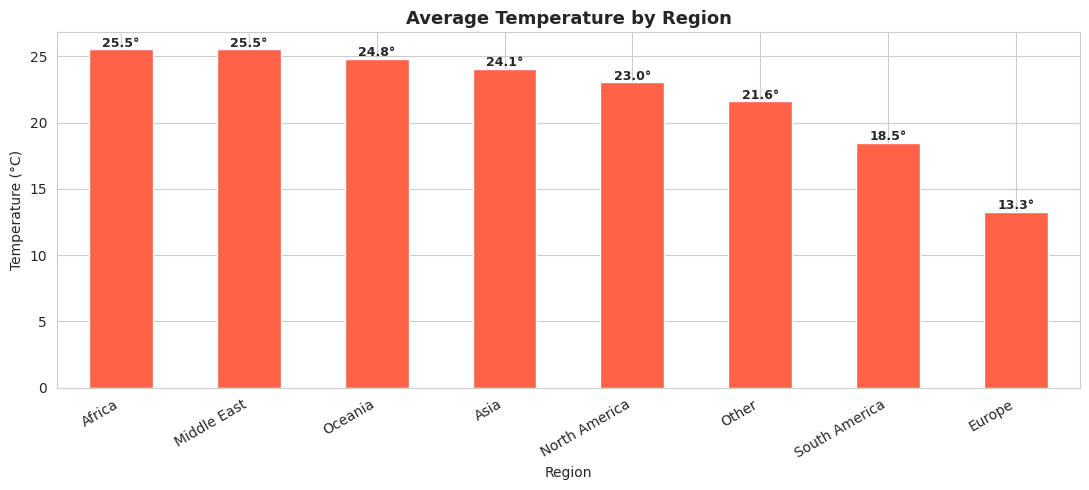

/tmp/ipython-input-1734/49272900.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='temperature_celsius', order=order, palette='Set2')


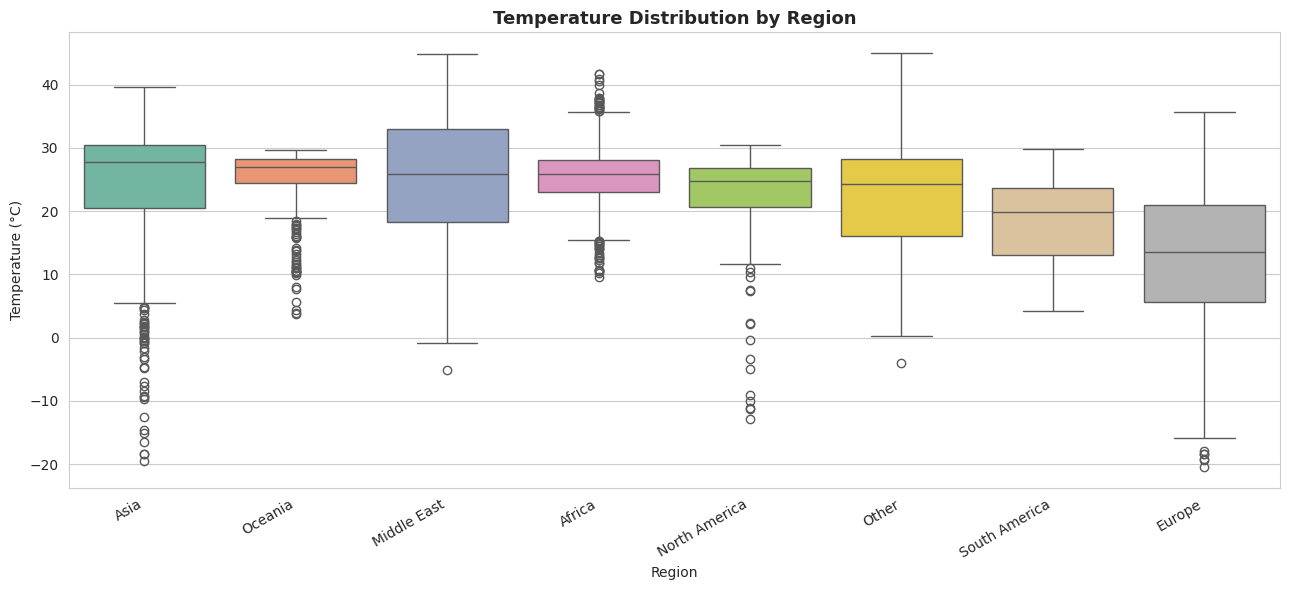

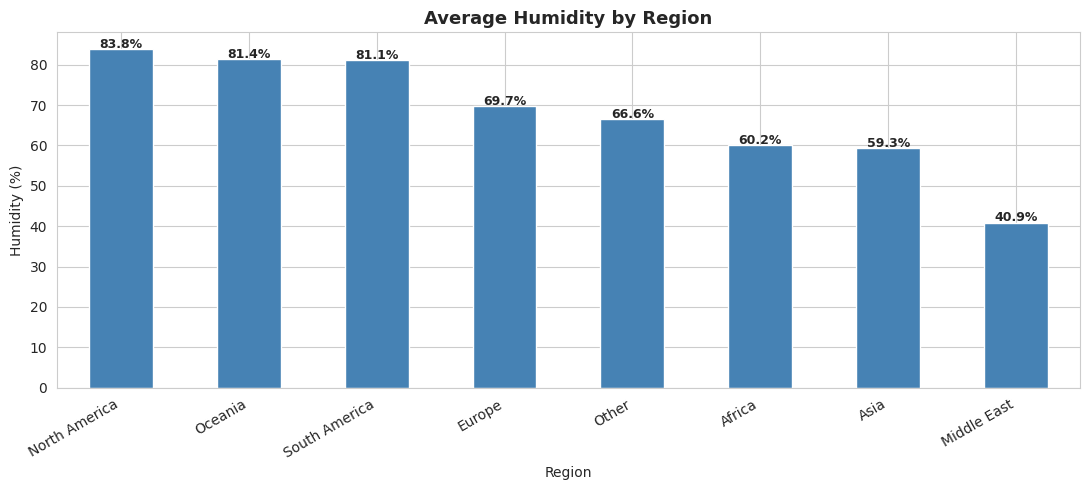

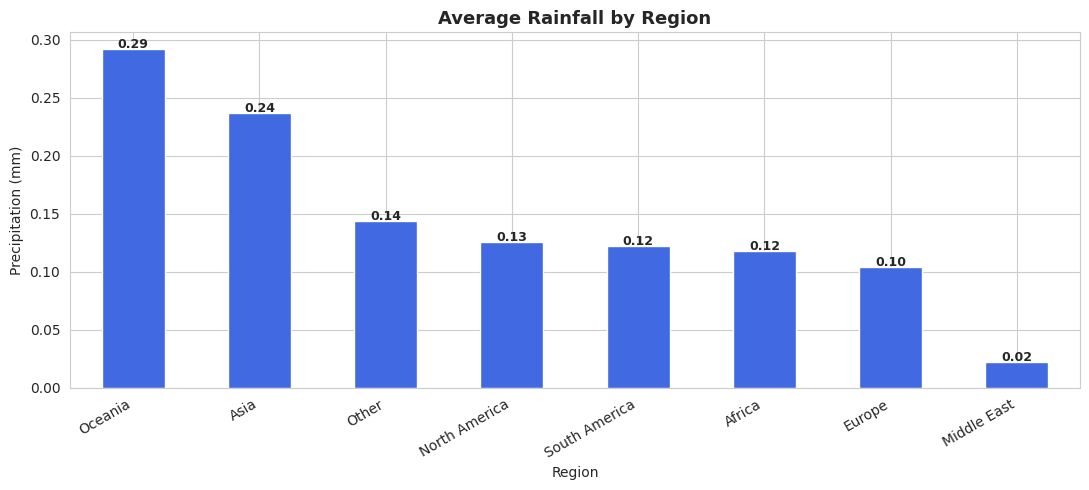

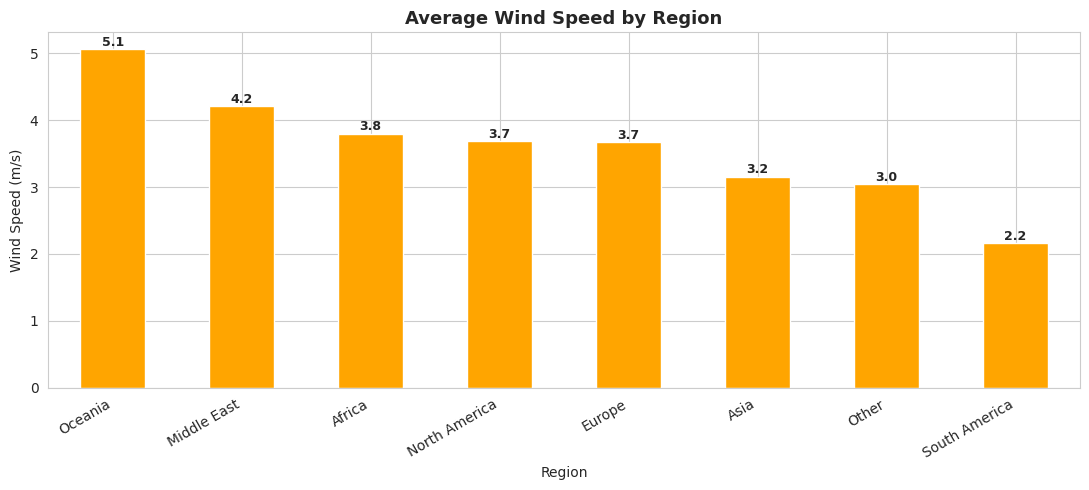

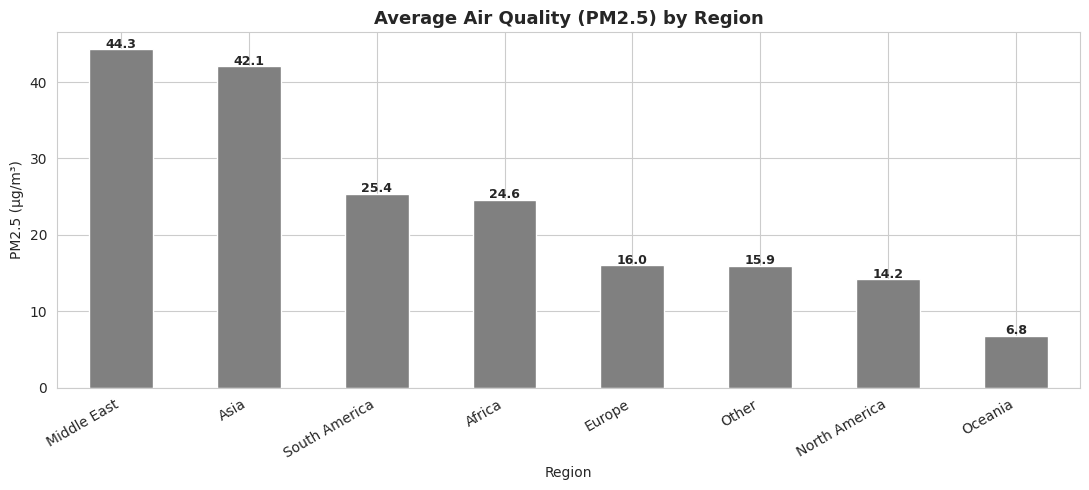

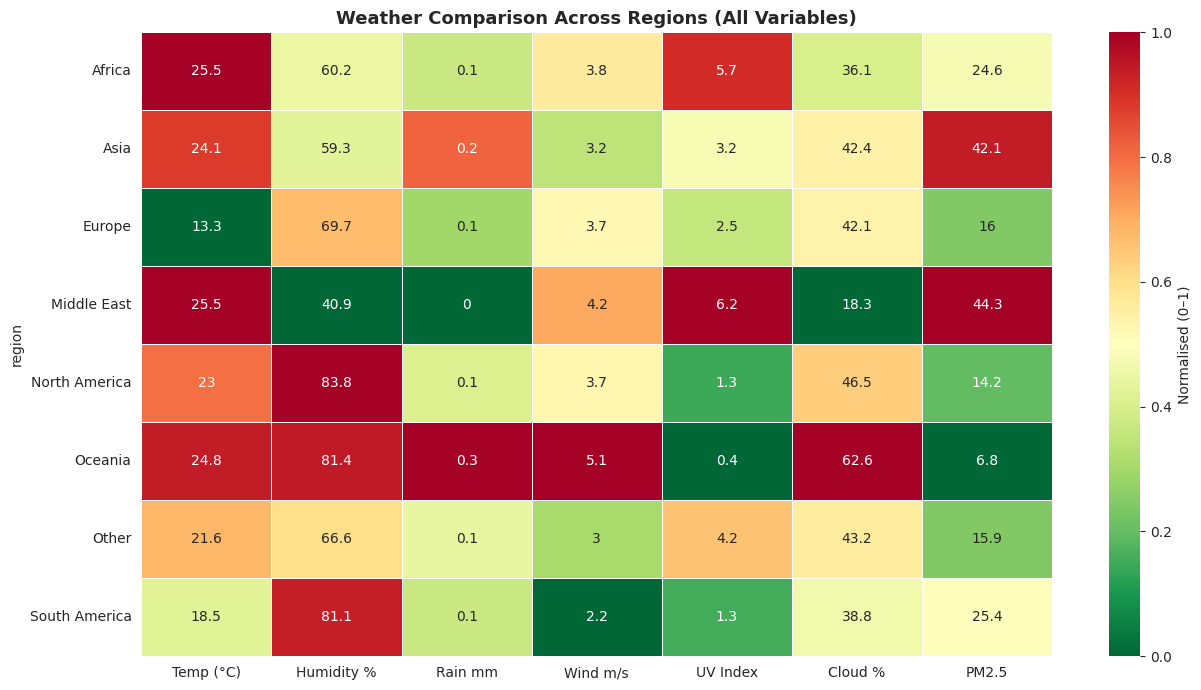

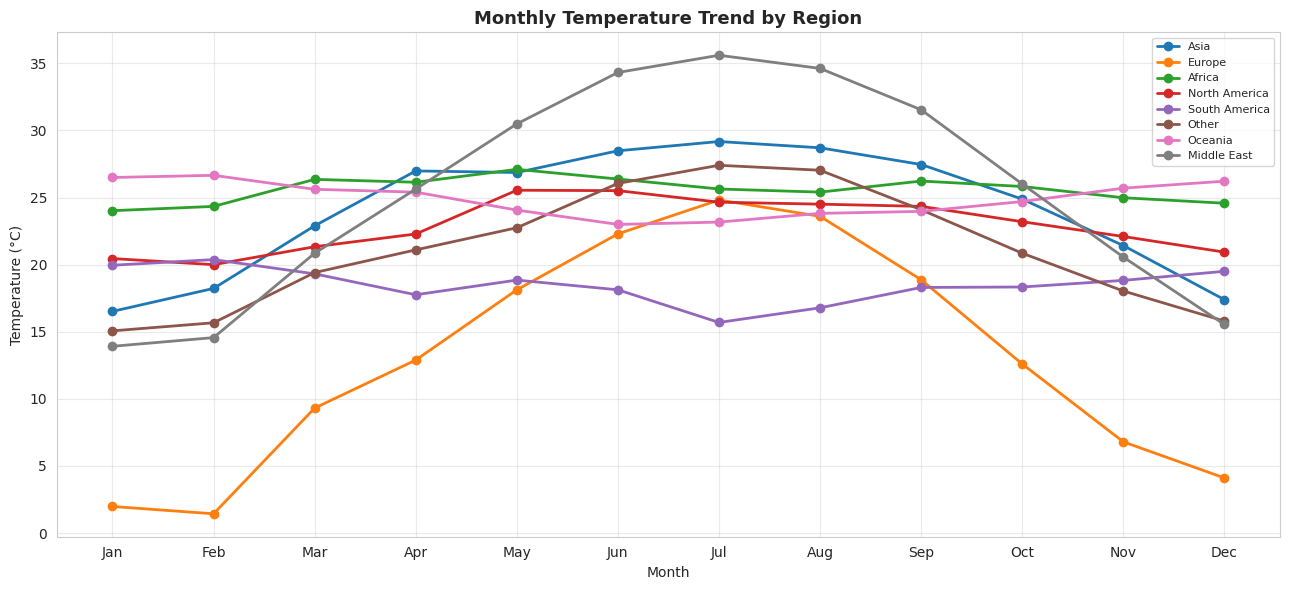

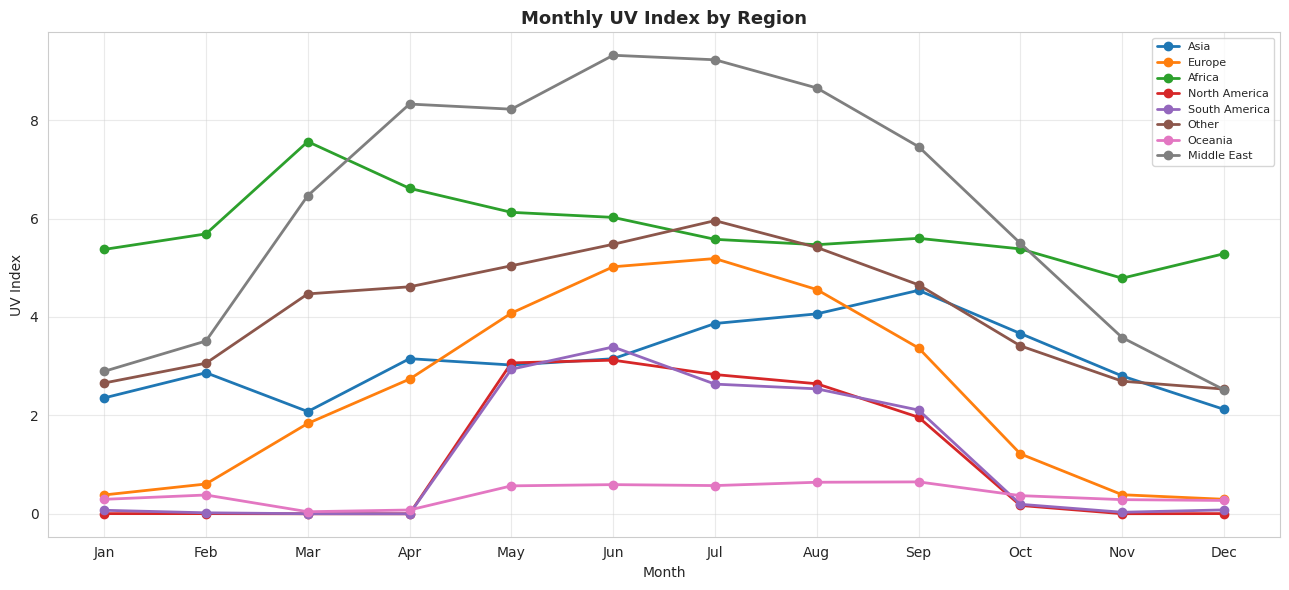

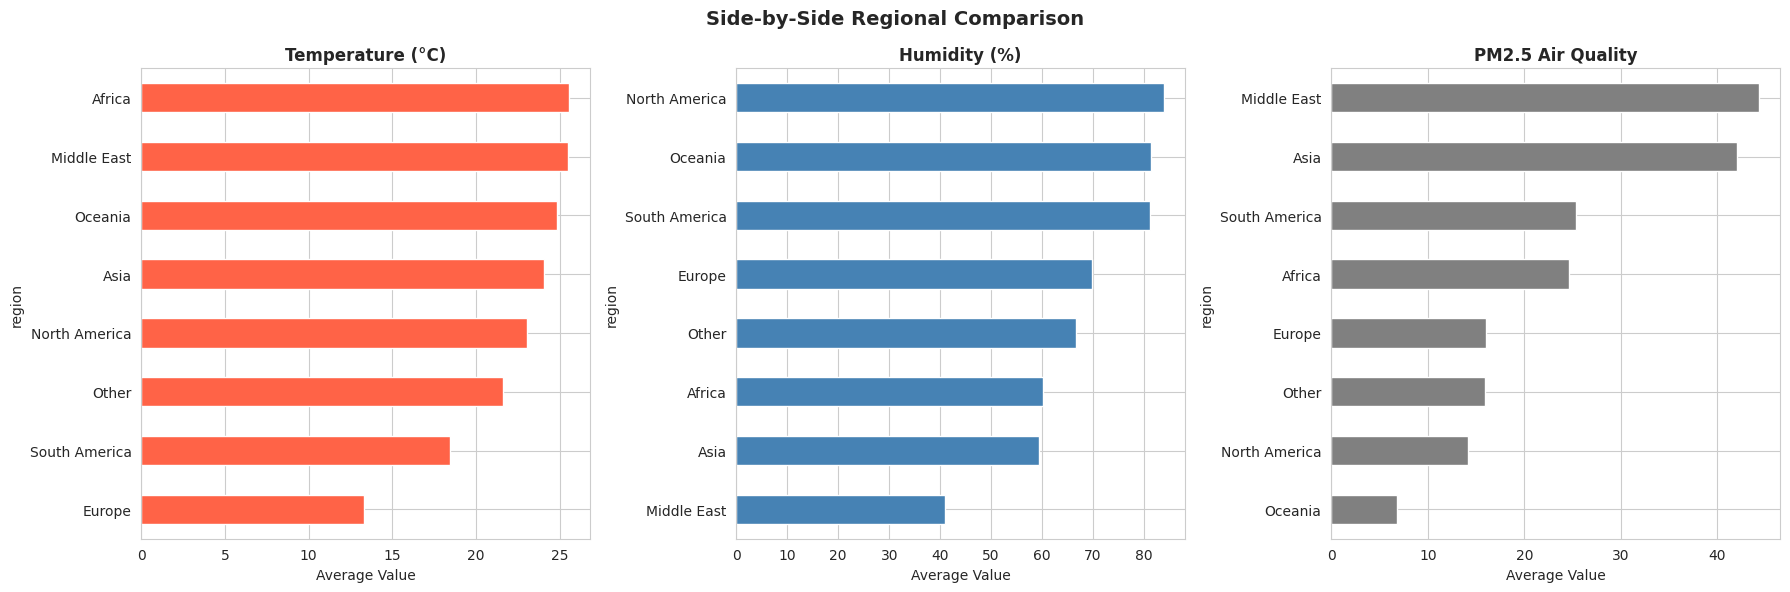

===== REGIONAL WEATHER SUMMARY =====

               Avg_Temp  Avg_Humidity  Avg_Wind  Avg_Rain  Avg_UV  Avg_PM25
region                                                                     
Africa            25.53         60.15      3.80      0.12    5.68     24.61
Middle East       25.52         40.88      4.21      0.02    6.22     44.29
Oceania           24.81         81.44      5.06      0.29    0.43      6.82
Asia              24.07         59.31      3.16      0.24    3.19     42.08
North America     23.02         83.83      3.69      0.13    1.27     14.17
Other             21.61         66.58      3.05      0.14    4.25     15.93
South America     18.46         81.12      2.16      0.12    1.33     25.40
Europe            13.28         69.71      3.67      0.10    2.50     16.03

✅ Done! All regions compared.


In [35]:
# =====================================================
#   COMPARE WEATHER CONDITIONS ACROSS REGIONS
#   Dataset: cleaned_global_weather_monthly.csv
# =====================================================


# CELL 1 - Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries loaded!")


# CELL 2 - Load Dataset
df = pd.read_csv('cleaned_global_weather_monthly.csv')

print("✅ Dataset loaded!")
print("Rows     :", df.shape[0])
print("Countries:", df['country'].nunique())
df.head()


# CELL 3 - Assign Each Country to a World Region
region_map = {
    # Asia
    'Afghanistan':'Asia','Bangladesh':'Asia','Bhutan':'Asia','Cambodia':'Asia',
    'China':'Asia','India':'Asia','Indonesia':'Asia','Japan':'Asia','Kazakhstan':'Asia',
    'Kyrgyzstan':'Asia','Laos':'Asia','Malaysia':'Asia','Maldives':'Asia','Mongolia':'Asia',
    'Myanmar':'Asia','Nepal':'Asia','North Korea':'Asia','Pakistan':'Asia',
    'Philippines':'Asia','Singapore':'Asia','South Korea':'Asia','Sri Lanka':'Asia',
    'Taiwan':'Asia','Tajikistan':'Asia','Thailand':'Asia','Timor-Leste':'Asia',
    'Turkmenistan':'Asia','Uzbekistan':'Asia','Vietnam':'Asia',
    # Middle East
    'Bahrain':'Middle East','Cyprus':'Middle East','Iran':'Middle East','Iraq':'Middle East',
    'Israel':'Middle East','Jordan':'Middle East','Kuwait':'Middle East','Lebanon':'Middle East',
    'Oman':'Middle East','Qatar':'Middle East','Saudi Arabia':'Middle East','Syria':'Middle East',
    'Turkey':'Middle East','United Arab Emirates':'Middle East','Yemen':'Middle East',
    # Europe
    'Albania':'Europe','Andorra':'Europe','Austria':'Europe','Belarus':'Europe',
    'Belgium':'Europe','Bosnia and Herzegovina':'Europe','Bulgaria':'Europe','Croatia':'Europe',
    'Czech Republic':'Europe','Denmark':'Europe','Estonia':'Europe','Finland':'Europe',
    'France':'Europe','Germany':'Europe','Greece':'Europe','Hungary':'Europe',
    'Iceland':'Europe','Ireland':'Europe','Italy':'Europe','Latvia':'Europe',
    'Liechtenstein':'Europe','Lithuania':'Europe','Luxembourg':'Europe','Malta':'Europe',
    'Moldova':'Europe','Monaco':'Europe','Montenegro':'Europe','Netherlands':'Europe',
    'North Macedonia':'Europe','Norway':'Europe','Poland':'Europe','Portugal':'Europe',
    'Romania':'Europe','Russia':'Europe','San Marino':'Europe','Serbia':'Europe',
    'Slovakia':'Europe','Slovenia':'Europe','Spain':'Europe','Sweden':'Europe',
    'Switzerland':'Europe','Ukraine':'Europe','United Kingdom':'Europe',
    # Africa
    'Algeria':'Africa','Angola':'Africa','Benin':'Africa','Botswana':'Africa',
    'Burkina Faso':'Africa','Burundi':'Africa','Cameroon':'Africa','Cape Verde':'Africa',
    'Central African Republic':'Africa','Chad':'Africa','Comoros':'Africa',
    'Democratic Republic of the Congo':'Africa','Djibouti':'Africa','Egypt':'Africa',
    'Equatorial Guinea':'Africa','Eritrea':'Africa','Eswatini':'Africa','Ethiopia':'Africa',
    'Gabon':'Africa','Gambia':'Africa','Ghana':'Africa','Guinea':'Africa',
    'Guinea-Bissau':'Africa','Ivory Coast':'Africa','Kenya':'Africa','Lesotho':'Africa',
    'Liberia':'Africa','Libya':'Africa','Madagascar':'Africa','Malawi':'Africa',
    'Mali':'Africa','Mauritania':'Africa','Mauritius':'Africa','Morocco':'Africa',
    'Mozambique':'Africa','Namibia':'Africa','Niger':'Africa','Nigeria':'Africa',
    'Republic of the Congo':'Africa','Rwanda':'Africa','Sao Tome and Principe':'Africa',
    'Senegal':'Africa','Seychelles':'Africa','Sierra Leone':'Africa','Somalia':'Africa',
    'South Africa':'Africa','South Sudan':'Africa','Sudan':'Africa','Tanzania':'Africa',
    'Togo':'Africa','Tunisia':'Africa','Uganda':'Africa','Zambia':'Africa','Zimbabwe':'Africa',
    # North America
    'Antigua and Barbuda':'North America','Bahamas':'North America','Barbados':'North America',
    'Belize':'North America','Canada':'North America','Costa Rica':'North America',
    'Cuba':'North America','Dominica':'North America','Dominican Republic':'North America',
    'El Salvador':'North America','Grenada':'North America','Guatemala':'North America',
    'Haiti':'North America','Honduras':'North America','Jamaica':'North America',
    'Mexico':'North America','Nicaragua':'North America','Panama':'North America',
    'Saint Kitts and Nevis':'North America','Saint Lucia':'North America',
    'Saint Vincent and the Grenadines':'North America','Trinidad and Tobago':'North America',
    'United States':'North America',
    # South America
    'Argentina':'South America','Bolivia':'South America','Brazil':'South America',
    'Chile':'South America','Colombia':'South America','Ecuador':'South America',
    'Guyana':'South America','Paraguay':'South America','Peru':'South America',
    'Suriname':'South America','Uruguay':'South America','Venezuela':'South America',
    # Oceania
    'Australia':'Oceania','Fiji':'Oceania','Kiribati':'Oceania','Marshall Islands':'Oceania',
    'Micronesia':'Oceania','Nauru':'Oceania','New Zealand':'Oceania','Palau':'Oceania',
    'Papua New Guinea':'Oceania','Samoa':'Oceania','Solomon Islands':'Oceania',
    'Tonga':'Oceania','Tuvalu':'Oceania','Vanuatu':'Oceania',
}

df['region'] = df['country'].map(region_map).fillna('Other')

print("✅ Regions assigned!")
print(df['region'].value_counts())


# CELL 4 - Average Weather by Region
num_cols = ['temperature_celsius','wind_mps','pressure_pa',
            'precip_mm','humidity','cloud','uv_index',
            'air_quality_PM2.5','air_quality_PM10']

region_avg = df.groupby('region')[num_cols].mean().round(2)
print("===== Average Weather by Region =====")
region_avg


# CELL 5 - Temperature by Region (Bar Chart)
temp_by_region = df.groupby('region')['temperature_celsius'].mean().sort_values(ascending=False)

plt.figure(figsize=(11, 5))
temp_by_region.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Average Temperature by Region', fontsize=13, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(temp_by_region):
    plt.text(i, v + 0.2, f'{v:.1f}°', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


# CELL 6 - Box Plot: Temperature Distribution by Region
plt.figure(figsize=(13, 6))
order = df.groupby('region')['temperature_celsius'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='region', y='temperature_celsius', order=order, palette='Set2')
plt.title('Temperature Distribution by Region', fontsize=13, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


# CELL 7 - Humidity by Region
humidity_by_region = df.groupby('region')['humidity'].mean().sort_values(ascending=False)

plt.figure(figsize=(11, 5))
humidity_by_region.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Average Humidity by Region', fontsize=13, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Humidity (%)')
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(humidity_by_region):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


# CELL 8 - Rainfall by Region
rain_by_region = df.groupby('region')['precip_mm'].mean().sort_values(ascending=False)

plt.figure(figsize=(11, 5))
rain_by_region.plot(kind='bar', color='royalblue', edgecolor='white')
plt.title('Average Rainfall by Region', fontsize=13, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Precipitation (mm)')
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(rain_by_region):
    plt.text(i, v + 0.001, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


# CELL 9 - Wind Speed by Region
wind_by_region = df.groupby('region')['wind_mps'].mean().sort_values(ascending=False)

plt.figure(figsize=(11, 5))
wind_by_region.plot(kind='bar', color='orange', edgecolor='white')
plt.title('Average Wind Speed by Region', fontsize=13, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Wind Speed (m/s)')
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(wind_by_region):
    plt.text(i, v + 0.05, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


# CELL 10 - Air Quality (PM2.5) by Region
air_by_region = df.groupby('region')['air_quality_PM2.5'].mean().sort_values(ascending=False)

plt.figure(figsize=(11, 5))
air_by_region.plot(kind='bar', color='gray', edgecolor='white')
plt.title('Average Air Quality (PM2.5) by Region', fontsize=13, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('PM2.5 (µg/m³)')
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(air_by_region):
    plt.text(i, v + 0.2, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


# CELL 11 - Heatmap: All Weather Variables by Region
plt.figure(figsize=(13, 7))
heat_data = region_avg[['temperature_celsius','humidity','precip_mm',
                         'wind_mps','uv_index','cloud','air_quality_PM2.5']]
heat_data.columns = ['Temp (°C)','Humidity %','Rain mm',
                     'Wind m/s','UV Index','Cloud %','PM2.5']
heat_norm = heat_data.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=0)

sns.heatmap(heat_norm, annot=heat_data.round(1), fmt='g',
            cmap='RdYlGn_r', linewidths=0.5, cbar_kws={'label':'Normalised (0–1)'})
plt.title('Weather Comparison Across Regions (All Variables)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# CELL 12 - Seasonal Temperature Trends by Region
monthly_region = df.groupby(['region','month'])['temperature_celsius'].mean().reset_index()
regions = df['region'].unique()
colors  = sns.color_palette('tab10', len(regions))

plt.figure(figsize=(13, 6))
for reg, col in zip(regions, colors):
    subset = monthly_region[monthly_region['region'] == reg]
    plt.plot(subset['month'], subset['temperature_celsius'],
             marker='o', label=reg, linewidth=2, color=col)

plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Monthly Temperature Trend by Region', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.legend(loc='upper right', fontsize=8)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()


# CELL 13 - UV Index by Region (Monthly)
monthly_uv = df.groupby(['region','month'])['uv_index'].mean().reset_index()

plt.figure(figsize=(13, 6))
for reg, col in zip(regions, colors):
    subset = monthly_uv[monthly_uv['region'] == reg]
    plt.plot(subset['month'], subset['uv_index'],
             marker='o', label=reg, linewidth=2, color=col)

plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Monthly UV Index by Region', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('UV Index')
plt.legend(loc='upper right', fontsize=8)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()


# CELL 14 - Side-by-Side Comparison: Top 3 Metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['temperature_celsius', 'humidity', 'air_quality_PM2.5']
titles  = ['Temperature (°C)', 'Humidity (%)', 'PM2.5 Air Quality']
colors2 = ['tomato', 'steelblue', 'gray']

for ax, metric, title, clr in zip(axes, metrics, titles, colors2):
    data = df.groupby('region')[metric].mean().sort_values(ascending=False)
    data.plot(kind='barh', ax=ax, color=clr, edgecolor='white')
    ax.invert_yaxis()
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Average Value')

plt.suptitle('Side-by-Side Regional Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# CELL 15 - Final Summary Table
print("===== REGIONAL WEATHER SUMMARY =====\n")
summary = df.groupby('region').agg(
    Avg_Temp      = ('temperature_celsius', 'mean'),
    Avg_Humidity  = ('humidity', 'mean'),
    Avg_Wind      = ('wind_mps', 'mean'),
    Avg_Rain      = ('precip_mm', 'mean'),
    Avg_UV        = ('uv_index', 'mean'),
    Avg_PM25      = ('air_quality_PM2.5', 'mean')
).round(2)

print(summary.sort_values('Avg_Temp', ascending=False).to_string())
print("\n✅ Done! All regions compared.")

✅ Libraries loaded!
✅ Data loaded!
Rows     : 4385
Countries: 211


/tmp/ipython-input-1734/1483486392.py:124: UserWarning:

Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.



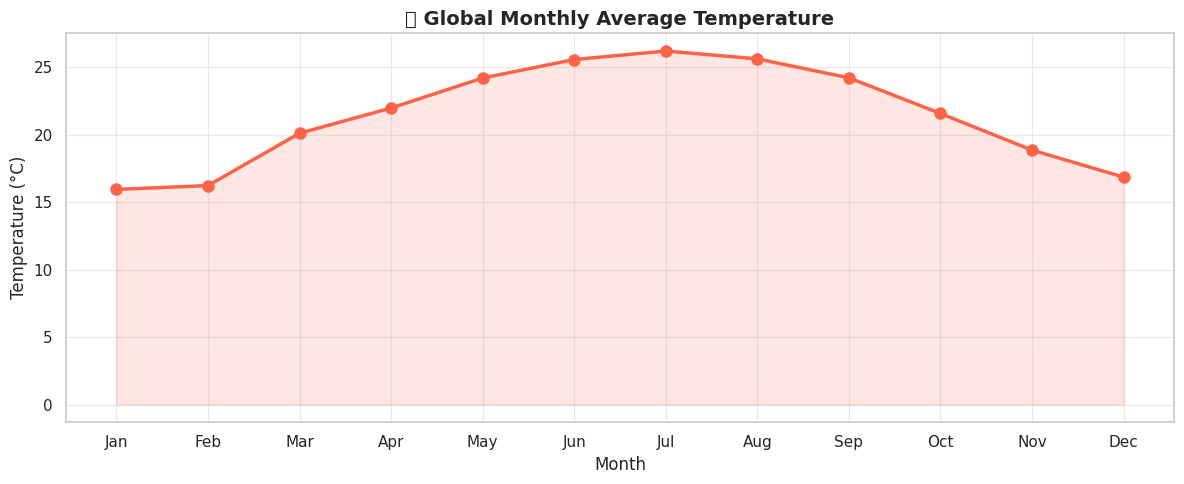

/tmp/ipython-input-1734/1483486392.py:135: UserWarning:

Glyph 128167 (\N{DROPLET}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128167 (\N{DROPLET}) missing from font(s) DejaVu Sans.



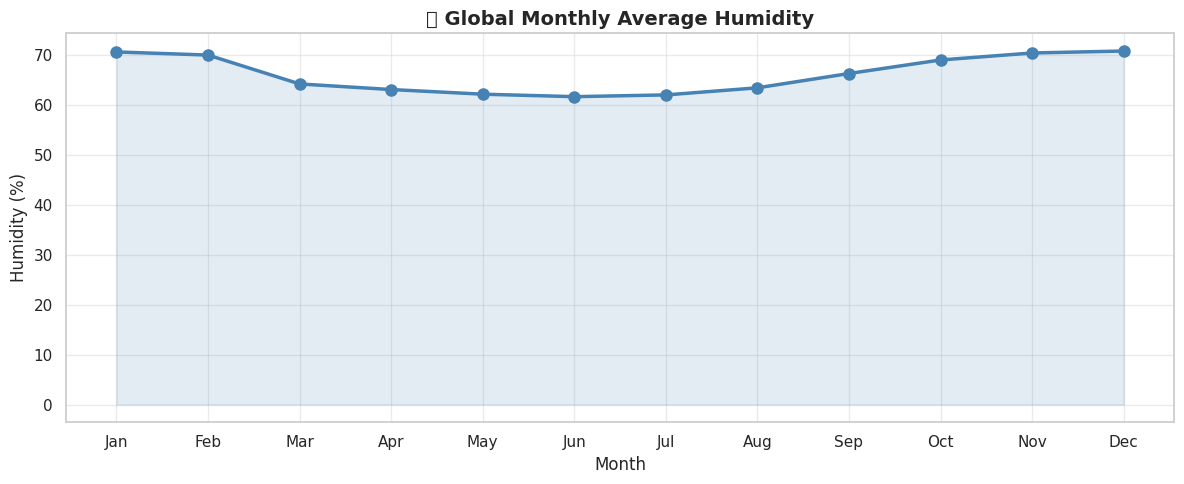

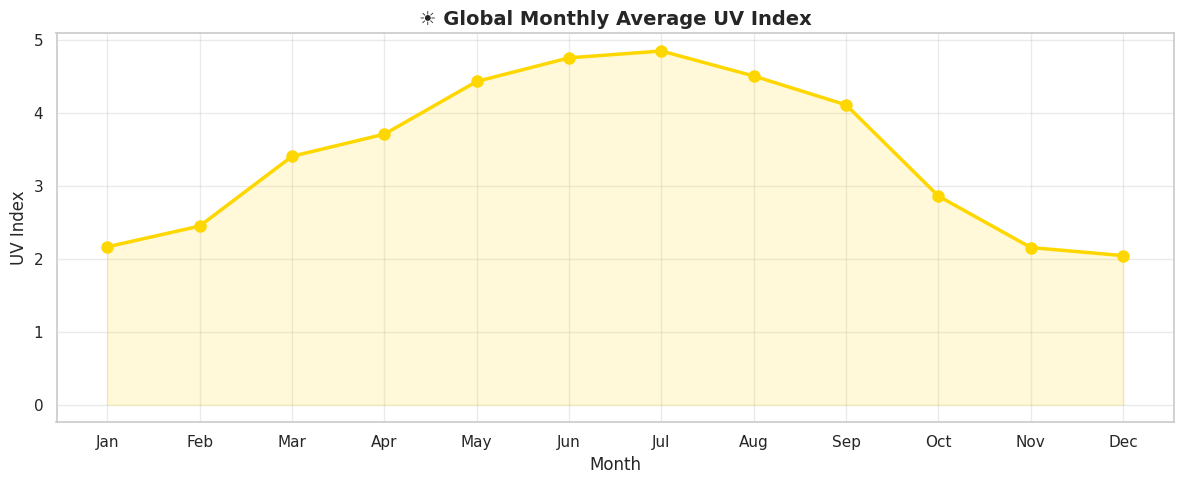

/tmp/ipython-input-1734/1483486392.py:157: UserWarning:

Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.



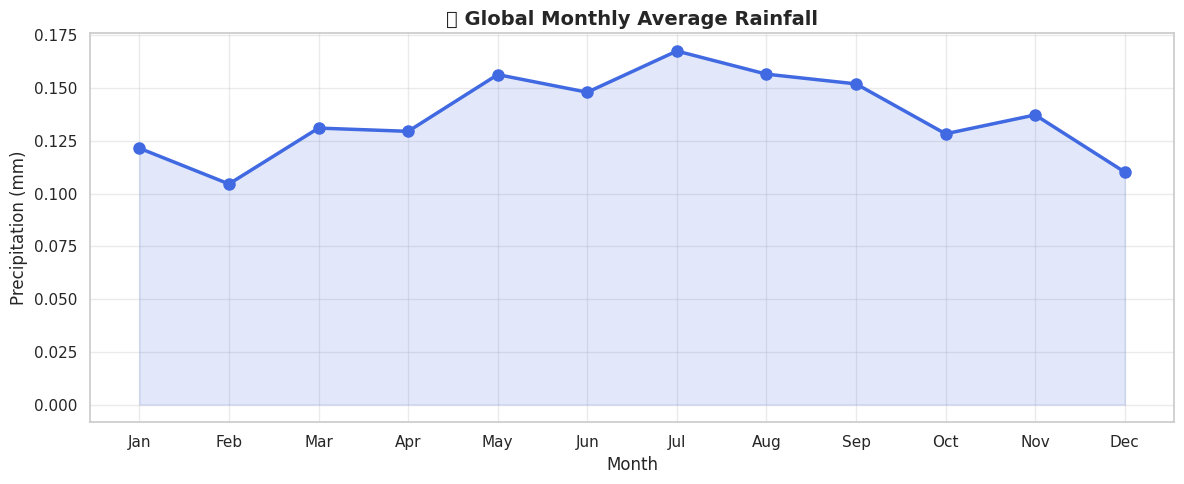

/tmp/ipython-input-1734/1483486392.py:177: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.



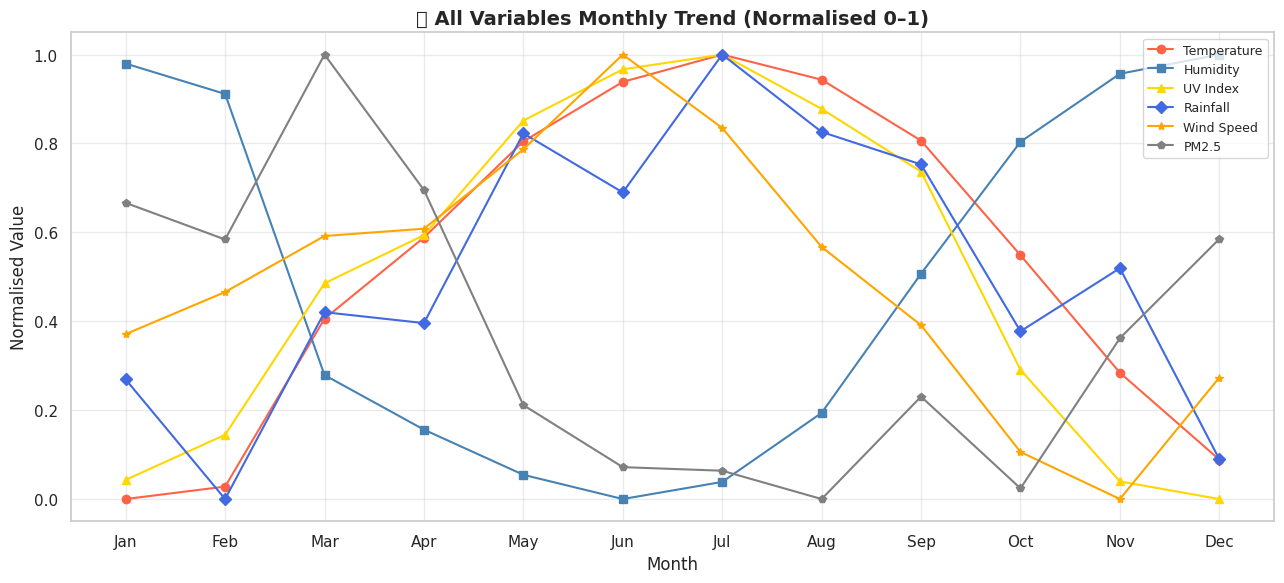

/tmp/ipython-input-1734/1483486392.py:192: UserWarning:

Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.



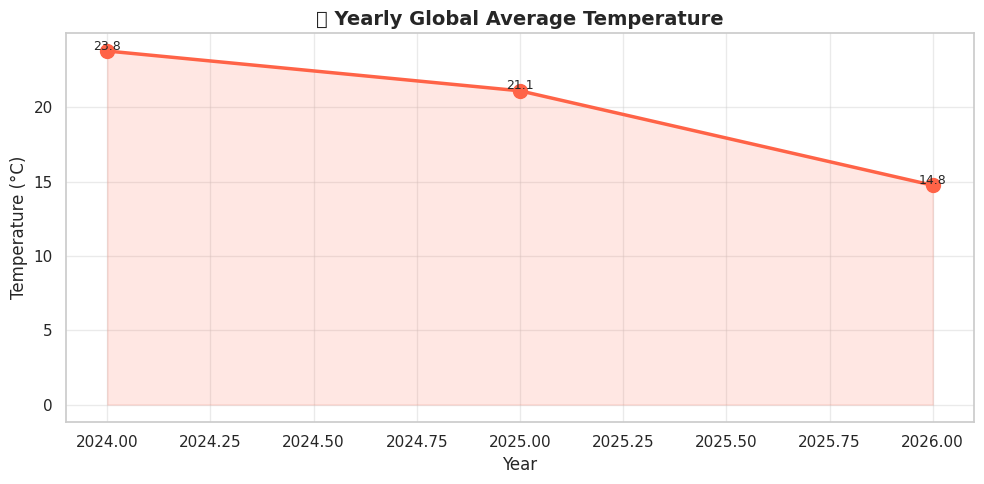

/tmp/ipython-input-1734/1483486392.py:212: UserWarning:

Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.



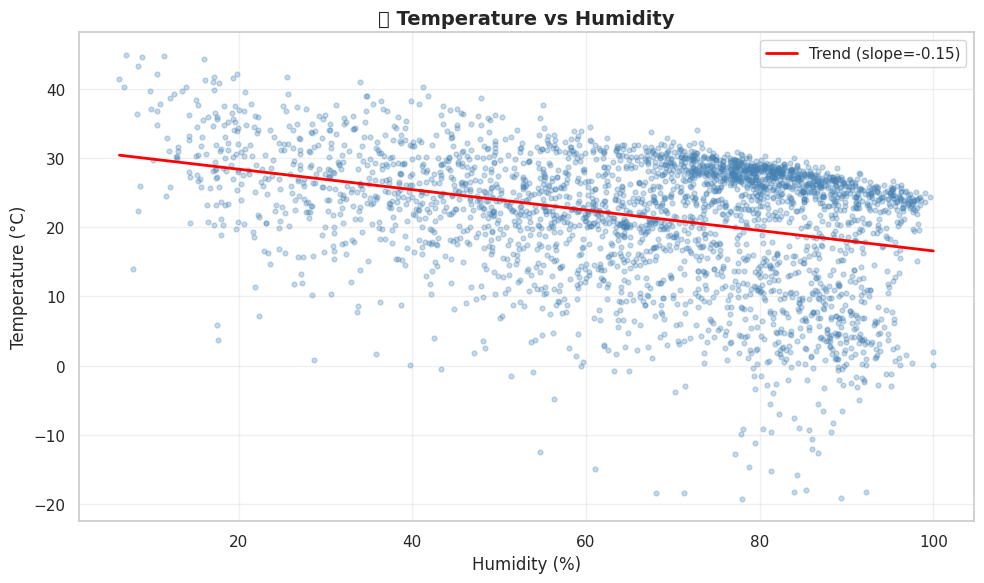

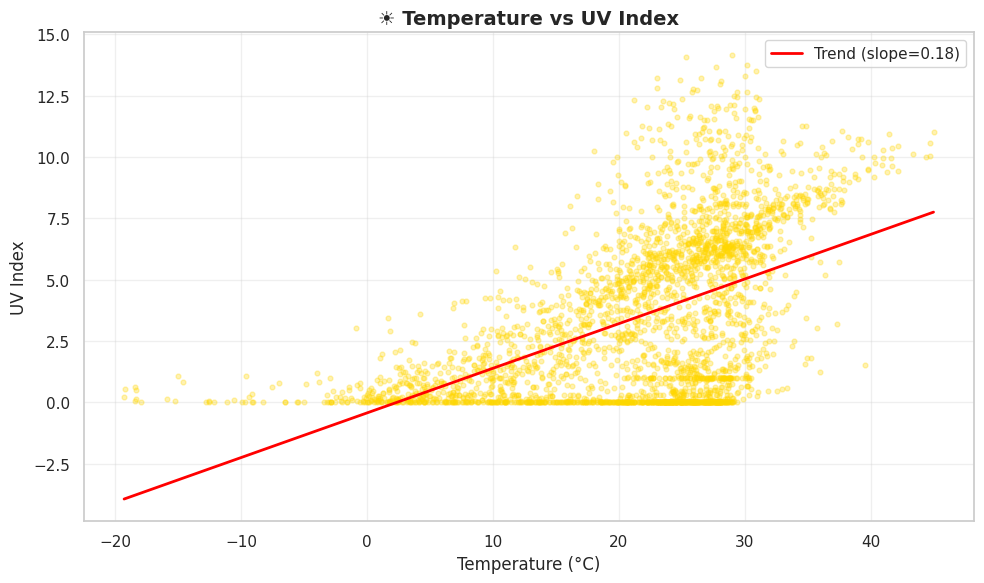

/tmp/ipython-input-1734/1483486392.py:236: UserWarning:

Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.



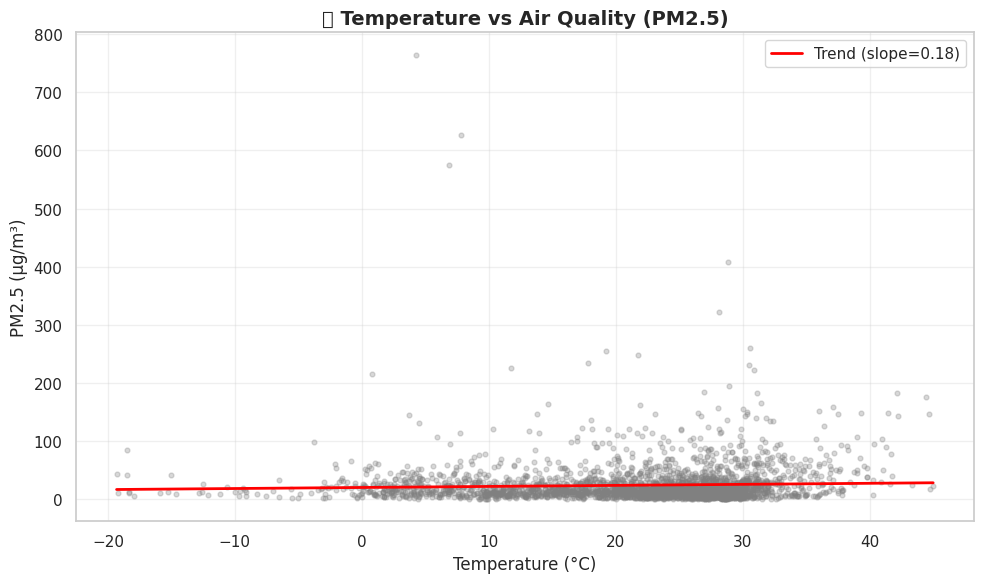

/tmp/ipython-input-1734/1483486392.py:248: UserWarning:

Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) DejaVu Sans.



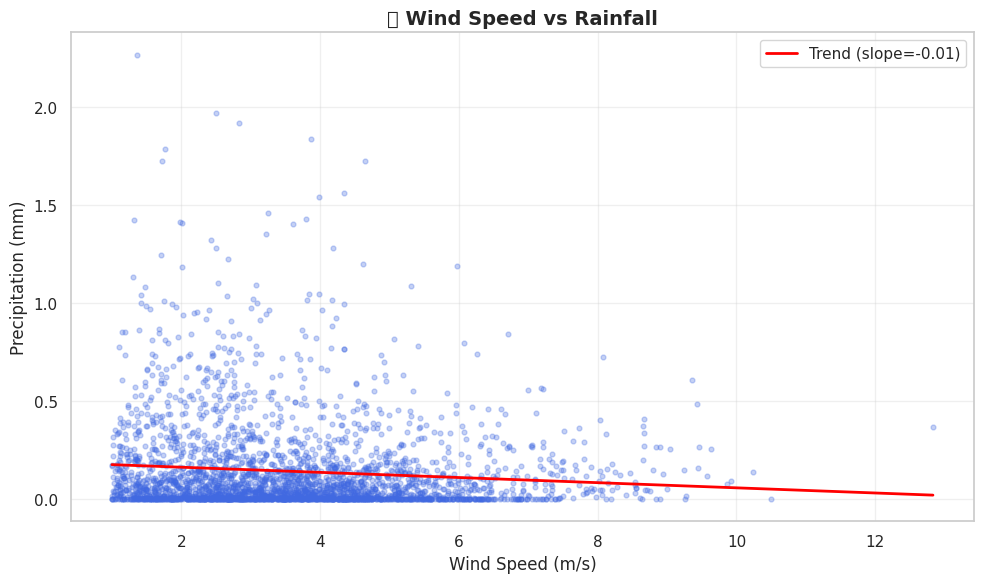

/tmp/ipython-input-1734/1483486392.py:281: UserWarning:

Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.



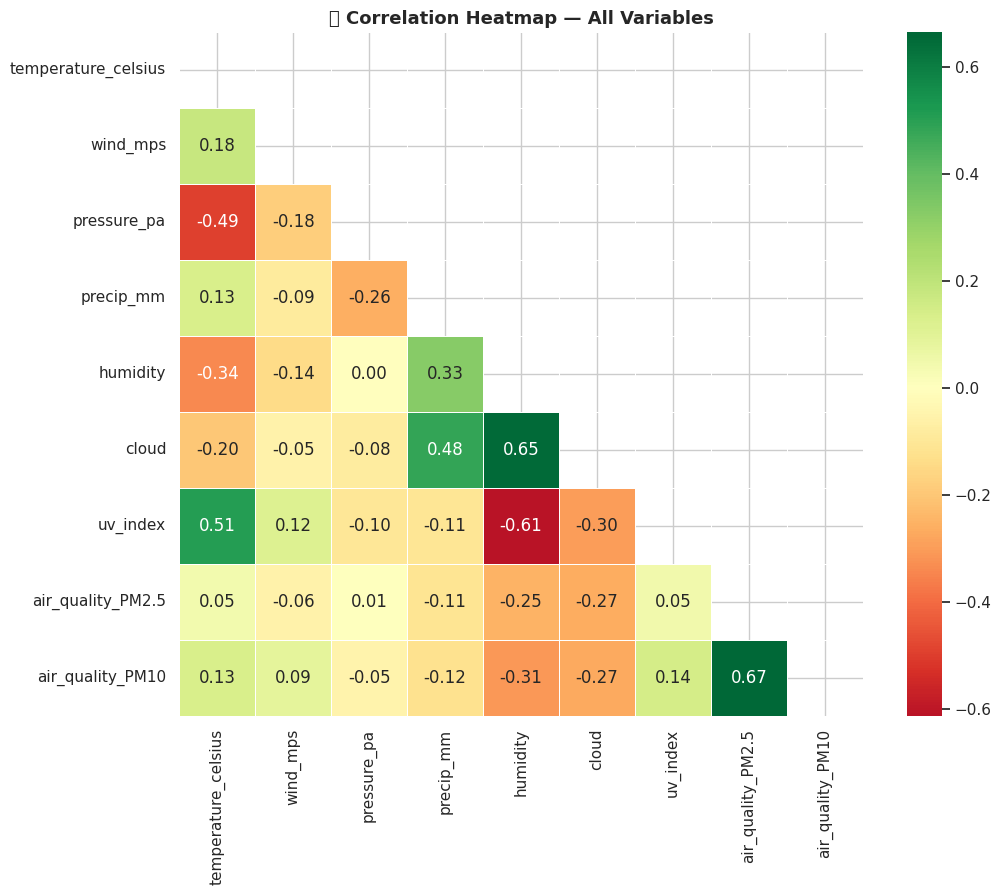

/tmp/ipython-input-1734/1483486392.py:295: UserWarning:

Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.



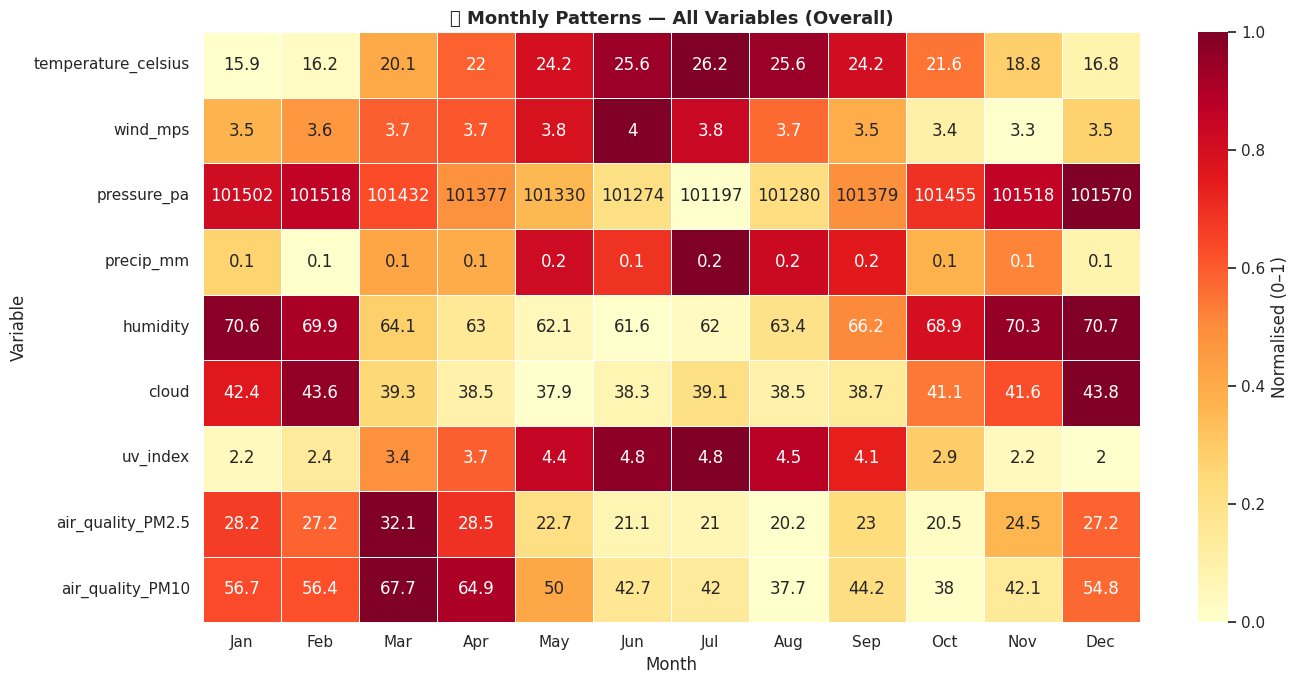

/tmp/ipython-input-1734/1483486392.py:307: UserWarning:

Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.



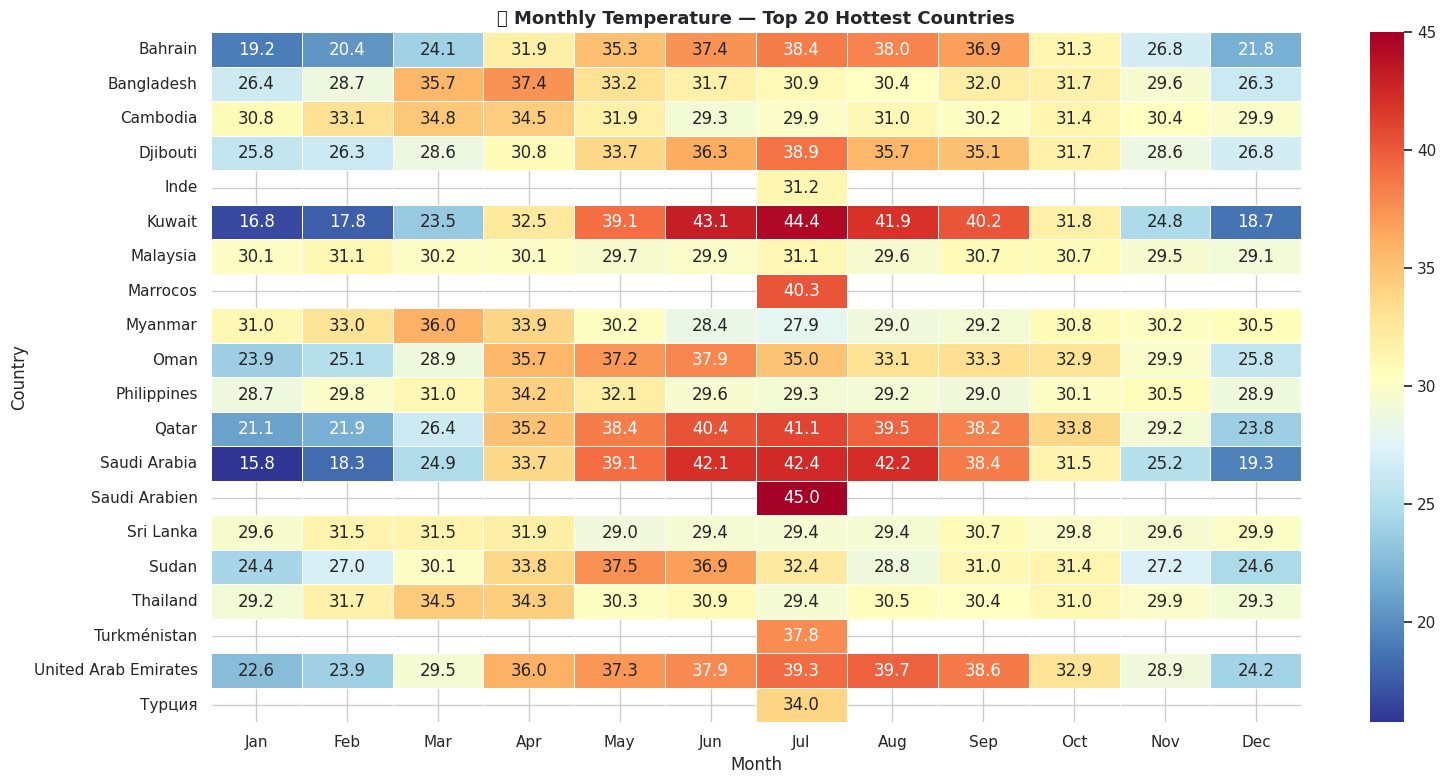

/tmp/ipython-input-1734/1483486392.py:319: UserWarning:

Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.



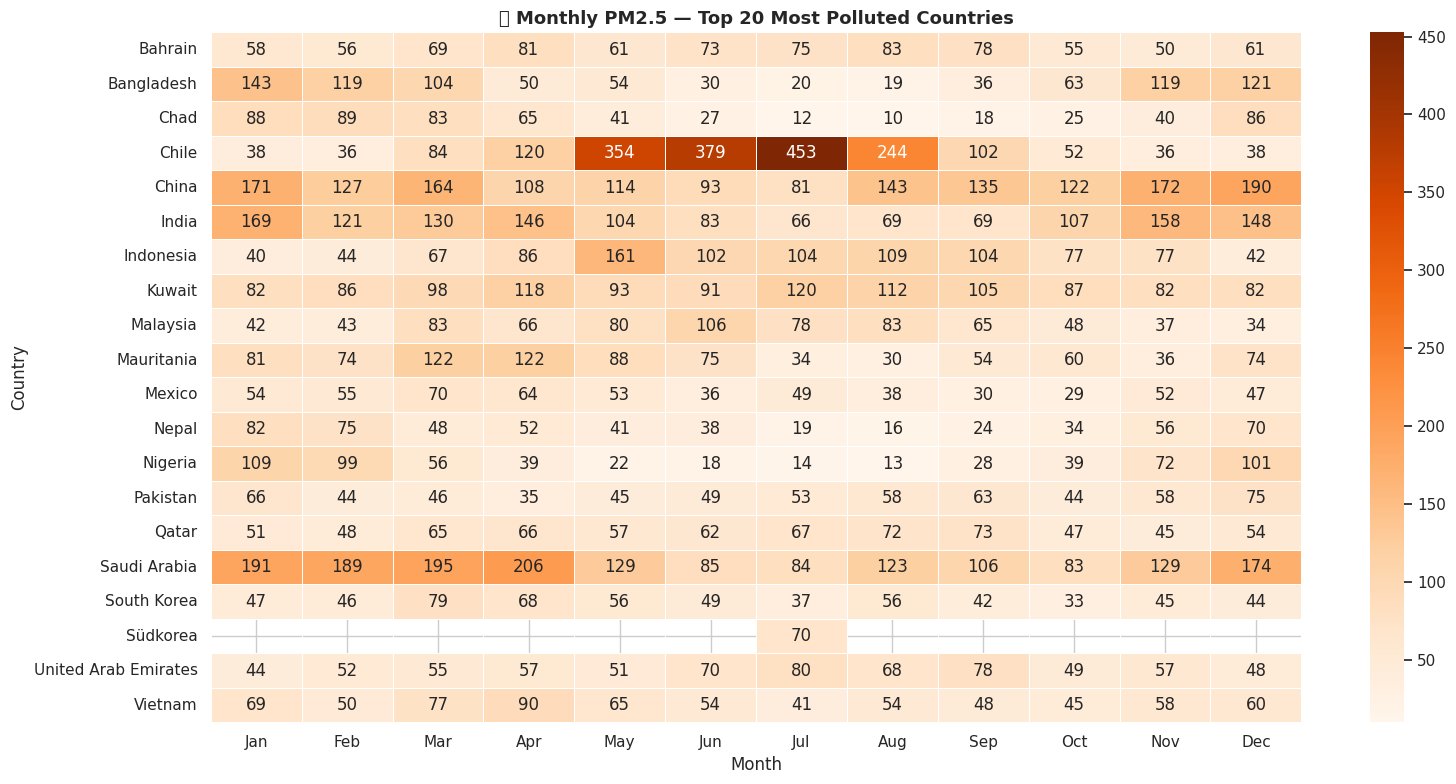

     VISUALIZATION SUMMARY
🗺️  Choropleth  → Temp, Humidity, PM2.5, UV (all countries)
📈 Line Charts → Monthly & Yearly global trends
🔵 Scatter     → Temp vs Humidity, UV, PM2.5, Wind
🟥 Heatmaps    → Correlations, Monthly patterns, Country-wise
Total Records : 4385
Countries     : 211
Year range    : 2024 – 2026


In [37]:
# ================================================================
#   WEATHER DATA VISUALIZATIONS - OVERALL (No Regions)
#   Choropleth Maps | Line Charts | Scatterplots | Heatmaps
#   Dataset: cleaned_global_weather_monthly.csv
# ================================================================


# CELL 1 - Install Plotly
# !pip install plotly


# CELL 2 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (13, 6)
print("✅ Libraries loaded!")


# CELL 3 - Load Dataset
df = pd.read_csv('cleaned_global_weather_monthly.csv')
print("✅ Data loaded!")
print("Rows     :", df.shape[0])
print("Countries:", df['country'].nunique())
df.head()


# ================================================================
# SECTION A — CHOROPLETH MAPS
# ================================================================


#  Choropleth: Average Temperature by Country
country_temp = df.groupby('country')['temperature_celsius'].mean().reset_index()
country_temp.columns = ['country', 'avg_temp']

fig = px.choropleth(
    country_temp,
    locations='country',
    locationmode='country names',
    color='avg_temp',
    color_continuous_scale='RdYlBu_r',
    title='🌡️ Average Temperature by Country (°C)',
    labels={'avg_temp': 'Avg Temp (°C)'}
)
fig.show()


# Choropleth: Average Humidity by Country
country_hum = df.groupby('country')['humidity'].mean().reset_index()
country_hum.columns = ['country', 'avg_humidity']

fig = px.choropleth(
    country_hum,
    locations='country',
    locationmode='country names',
    color='avg_humidity',
    color_continuous_scale='Blues',
    title='💧 Average Humidity by Country (%)',
    labels={'avg_humidity': 'Humidity (%)'}
)
fig.show()


#  Choropleth: Air Quality PM2.5 by Country
country_air = df.groupby('country')['air_quality_PM2.5'].mean().reset_index()
country_air.columns = ['country', 'avg_pm25']

fig = px.choropleth(
    country_air,
    locations='country',
    locationmode='country names',
    color='avg_pm25',
    color_continuous_scale='Oranges',
    title='🏭 Average Air Quality (PM2.5) by Country',
    labels={'avg_pm25': 'PM2.5 (µg/m³)'}
)
fig.show()


#  Choropleth: UV Index by Country
country_uv = df.groupby('country')['uv_index'].mean().reset_index()
country_uv.columns = ['country', 'avg_uv']

fig = px.choropleth(
    country_uv,
    locations='country',
    locationmode='country names',
    color='avg_uv',
    color_continuous_scale='YlOrRd',
    title='☀️ Average UV Index by Country',
    labels={'avg_uv': 'UV Index'}
)
fig.show()


# ================================================================
# SECTION B — LINE CHARTS
# ================================================================


# Line Chart: Monthly Average Temperature (Global)
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('month').agg(
    temperature_celsius = ('temperature_celsius','mean'),
    humidity            = ('humidity','mean'),
    precip_mm           = ('precip_mm','mean'),
    uv_index            = ('uv_index','mean'),
    wind_mps            = ('wind_mps','mean'),
    air_quality_PM2_5   = ('air_quality_PM2.5','mean')
).reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly['month'], monthly['temperature_celsius'],
         marker='o', linewidth=2.5, color='tomato', markersize=8)
plt.fill_between(monthly['month'], monthly['temperature_celsius'], alpha=0.15, color='tomato')
plt.xticks(range(1,13), months)
plt.title('🌡️ Global Monthly Average Temperature', fontsize=14, fontweight='bold')
plt.xlabel('Month'); plt.ylabel('Temperature (°C)')
plt.grid(alpha=0.4); plt.tight_layout(); plt.show()


#  Line Chart: Monthly Humidity
plt.figure(figsize=(12, 5))
plt.plot(monthly['month'], monthly['humidity'],
         marker='o', linewidth=2.5, color='steelblue', markersize=8)
plt.fill_between(monthly['month'], monthly['humidity'], alpha=0.15, color='steelblue')
plt.xticks(range(1,13), months)
plt.title('💧 Global Monthly Average Humidity', fontsize=14, fontweight='bold')
plt.xlabel('Month'); plt.ylabel('Humidity (%)')
plt.grid(alpha=0.4); plt.tight_layout(); plt.show()


#  Line Chart: Monthly UV Index
plt.figure(figsize=(12, 5))
plt.plot(monthly['month'], monthly['uv_index'],
         marker='o', linewidth=2.5, color='gold', markersize=8)
plt.fill_between(monthly['month'], monthly['uv_index'], alpha=0.15, color='gold')
plt.xticks(range(1,13), months)
plt.title('☀️ Global Monthly Average UV Index', fontsize=14, fontweight='bold')
plt.xlabel('Month'); plt.ylabel('UV Index')
plt.grid(alpha=0.4); plt.tight_layout(); plt.show()


# Line Chart: Monthly Rainfall
plt.figure(figsize=(12, 5))
plt.plot(monthly['month'], monthly['precip_mm'],
         marker='o', linewidth=2.5, color='royalblue', markersize=8)
plt.fill_between(monthly['month'], monthly['precip_mm'], alpha=0.15, color='royalblue')
plt.xticks(range(1,13), months)
plt.title('🌧️ Global Monthly Average Rainfall', fontsize=14, fontweight='bold')
plt.xlabel('Month'); plt.ylabel('Precipitation (mm)')
plt.grid(alpha=0.4); plt.tight_layout(); plt.show()


# Line Chart: All Variables Together (Normalised)
norm = monthly.copy()
for col in ['temperature_celsius','humidity','precip_mm','uv_index','wind_mps','air_quality_PM2_5']:
    norm[col] = (monthly[col] - monthly[col].min()) / (monthly[col].max() - monthly[col].min())

plt.figure(figsize=(13, 6))
plt.plot(norm['month'], norm['temperature_celsius'], marker='o', label='Temperature', color='tomato')
plt.plot(norm['month'], norm['humidity'],            marker='s', label='Humidity',    color='steelblue')
plt.plot(norm['month'], norm['uv_index'],            marker='^', label='UV Index',    color='gold')
plt.plot(norm['month'], norm['precip_mm'],           marker='D', label='Rainfall',    color='royalblue')
plt.plot(norm['month'], norm['wind_mps'],            marker='*', label='Wind Speed',  color='orange')
plt.plot(norm['month'], norm['air_quality_PM2_5'],   marker='p', label='PM2.5',       color='gray')

plt.xticks(range(1,13), months)
plt.title('📈 All Variables Monthly Trend (Normalised 0–1)', fontsize=14, fontweight='bold')
plt.xlabel('Month'); plt.ylabel('Normalised Value')
plt.legend(loc='upper right', fontsize=9)
plt.grid(alpha=0.4); plt.tight_layout(); plt.show()


# Line Chart: Yearly Temperature Trend
yearly = df.groupby('year')['temperature_celsius'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(yearly['year'], yearly['temperature_celsius'],
         marker='o', linewidth=2.5, color='tomato', markersize=10)
plt.fill_between(yearly['year'], yearly['temperature_celsius'], alpha=0.15, color='tomato')
for _, row in yearly.iterrows():
    plt.text(row['year'], row['temperature_celsius'] + 0.1,
             f"{row['temperature_celsius']:.1f}", ha='center', fontsize=9)
plt.title('📅 Yearly Global Average Temperature', fontsize=14, fontweight='bold')
plt.xlabel('Year'); plt.ylabel('Temperature (°C)')
plt.grid(alpha=0.4); plt.tight_layout(); plt.show()


# ================================================================
# SECTION C — SCATTERPLOTS
# ================================================================


# Scatterplot: Temperature vs Humidity
sample = df.sample(min(3000, len(df)), random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample['humidity'], sample['temperature_celsius'],
            alpha=0.3, s=12, color='steelblue')
# Trend line
m, b = np.polyfit(sample['humidity'], sample['temperature_celsius'], 1)
x_line = np.linspace(sample['humidity'].min(), sample['humidity'].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'Trend (slope={m:.2f})')
plt.title('🌡️ Temperature vs Humidity', fontsize=14, fontweight='bold')
plt.xlabel('Humidity (%)'); plt.ylabel('Temperature (°C)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


# Scatterplot: Temperature vs UV Index
plt.figure(figsize=(10, 6))
plt.scatter(sample['temperature_celsius'], sample['uv_index'],
            alpha=0.3, s=12, color='gold')
m, b = np.polyfit(sample['temperature_celsius'], sample['uv_index'], 1)
x_line = np.linspace(sample['temperature_celsius'].min(), sample['temperature_celsius'].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'Trend (slope={m:.2f})')
plt.title('☀️ Temperature vs UV Index', fontsize=14, fontweight='bold')
plt.xlabel('Temperature (°C)'); plt.ylabel('UV Index')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


#  Scatterplot: Temperature vs PM2.5
plt.figure(figsize=(10, 6))
plt.scatter(sample['temperature_celsius'], sample['air_quality_PM2.5'],
            alpha=0.3, s=12, color='gray')
m, b = np.polyfit(sample['temperature_celsius'], sample['air_quality_PM2.5'], 1)
x_line = np.linspace(sample['temperature_celsius'].min(), sample['temperature_celsius'].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'Trend (slope={m:.2f})')
plt.title('🏭 Temperature vs Air Quality (PM2.5)', fontsize=14, fontweight='bold')
plt.xlabel('Temperature (°C)'); plt.ylabel('PM2.5 (µg/m³)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


# Scatterplot: Wind vs Rainfall
plt.figure(figsize=(10, 6))
plt.scatter(sample['wind_mps'], sample['precip_mm'],
            alpha=0.3, s=12, color='royalblue')
m, b = np.polyfit(sample['wind_mps'], sample['precip_mm'], 1)
x_line = np.linspace(sample['wind_mps'].min(), sample['wind_mps'].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'Trend (slope={m:.2f})')
plt.title('💨 Wind Speed vs Rainfall', fontsize=14, fontweight='bold')
plt.xlabel('Wind Speed (m/s)'); plt.ylabel('Precipitation (mm)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


#Interactive Scatterplot: Temperature vs Humidity (Plotly)
fig = px.scatter(
    sample,
    x='humidity',
    y='temperature_celsius',
    color='month',
    hover_data=['country', 'month', 'year'],
    title='🌡️ Temperature vs Humidity (Interactive — colored by Month)',
    labels={'humidity':'Humidity (%)', 'temperature_celsius':'Temperature (°C)'},
    opacity=0.6,
    color_continuous_scale='RdYlBu_r'
)
fig.show()


# ================================================================
# SECTION D — HEATMAPS
# ================================================================


# Heatmap: Correlation Between All Variables
num_cols = ['temperature_celsius','wind_mps','pressure_pa','precip_mm',
            'humidity','cloud','uv_index','air_quality_PM2.5','air_quality_PM10']

plt.figure(figsize=(11, 9))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True, linewidths=0.5)
plt.title('🔗 Correlation Heatmap — All Variables', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


#  Heatmap: Monthly Average of All Variables
monthly_all = df.groupby('month')[num_cols].mean()
monthly_all.index = months
monthly_norm = monthly_all.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=0)

plt.figure(figsize=(14, 7))
sns.heatmap(monthly_norm.T, annot=monthly_all.T.round(1), fmt='g',
            cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Normalised (0–1)'})
plt.title('📅 Monthly Patterns — All Variables (Overall)', fontsize=13, fontweight='bold')
plt.xlabel('Month'); plt.ylabel('Variable')
plt.tight_layout(); plt.show()


#  Heatmap: Top 20 Countries by Temperature
top20 = df.groupby('country')['temperature_celsius'].mean().sort_values(ascending=False).head(20).index
pivot = df[df['country'].isin(top20)].groupby(['country','month'])['temperature_celsius'].mean().unstack()
pivot.columns = months

plt.figure(figsize=(16, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlBu_r', linewidths=0.4)
plt.title('🌡️ Monthly Temperature — Top 20 Hottest Countries', fontsize=13, fontweight='bold')
plt.xlabel('Month'); plt.ylabel('Country')
plt.tight_layout(); plt.show()


#  Heatmap: Top 20 Countries by PM2.5
top20_air = df.groupby('country')['air_quality_PM2.5'].mean().sort_values(ascending=False).head(20).index
pivot_air = df[df['country'].isin(top20_air)].groupby(['country','month'])['air_quality_PM2.5'].mean().unstack()
pivot_air.columns = months

plt.figure(figsize=(16, 8))
sns.heatmap(pivot_air, annot=True, fmt='.0f', cmap='Oranges', linewidths=0.4)
plt.title('🏭 Monthly PM2.5 — Top 20 Most Polluted Countries', fontsize=13, fontweight='bold')
plt.xlabel('Month'); plt.ylabel('Country')
plt.tight_layout(); plt.show()


# Final Summary
print("=" * 50)
print("     VISUALIZATION SUMMARY")
print("=" * 50)
print("🗺️  Choropleth  → Temp, Humidity, PM2.5, UV (all countries)")
print("📈 Line Charts → Monthly & Yearly global trends")
print("🔵 Scatter     → Temp vs Humidity, UV, PM2.5, Wind")
print("🟥 Heatmaps    → Correlations, Monthly patterns, Country-wise")
print("=" * 50)
print(f"Total Records : {df.shape[0]}")
print(f"Countries     : {df['country'].nunique()}")
print(f"Year range    : {df['year'].min()} – {df['year'].max()}")